In [1]:
# BLOCK 1 — Set up the Python environment, project paths, reproducibility settings, run logging, and model-file integrity checks.

import hashlib
import json
import platform
import random
import sys
import time
from pathlib import Path

import numpy as np

assert sys.version_info[:2] == (3, 12), (
    f"Wrong kernel: {sys.version.split()[0]} - select 'Python 3.12 (Secure DMS)' (dms312)"
)

SEED = 42 
random.seed(SEED)
np.random.seed(SEED)

# --- paths -----------------------------------------------------------------
ROOT = Path(r"C:\Users\Ajitesh\Documents\Galway Notes\Adaptive Cybersecurity Project")
PROJ = ROOT / "dms_project_fixed_v3" / "dms_jupyter"          # this project
MODELS_DIR = PROJ / "models"
OUT_DIR = PROJ / "outputs"
# Full dataset paths - NEVER truncate (v7 pitfall #1: silent distraction-only load)
DMD_DISTRACTION = Path(r"C:\Users\Ajitesh\Documents\Galway Notes\Case Study in Cybersecurity Analytics\DMD Dataset\Distraction")
DMD_DROWSINESS = Path(r"C:\Users\Ajitesh\Documents\Galway Notes\Case Study in Cybersecurity Analytics\DMD Dataset\Drowsiness")
NUAA = ROOT / "datasets" / "NormalizedFace"

# --- provenance run log (rule: no number enters the thesis unless logged) ---
OUT_DIR.mkdir(exist_ok=True)
RUN_LOG = OUT_DIR / f"run_log_{time.strftime('%Y%m%d_%H%M%S')}.txt"

def log(*parts):
    line = " ".join(str(p) for p in parts)
    print(line)
    with RUN_LOG.open("a", encoding="utf-8") as fh:
        fh.write(line + "\n")

# --- model artefact integrity (hashes recorded in REFERENCES.md) -----------
EXPECTED_HASHES = {
    "face_landmarker.task": "64184E229B263107BC2B804C6625DB1341FF2BB731874B0BCC2FE6544E0BC9FF",
    "L2CSNet_gaze360.pkl": "8A7F3480D868DD48261E1D59F915B0EF0BB33EA12EA00938FB2168F212080665",
    "6DRepNet_300W_LP_AFLW2000.pth": "9BDCD0E072DF0D21E92288B40EA1D1B3CF7173C44728AB9C45C4D673F361E018",
}

def verify_artefact(name: str) -> bool:
    path = MODELS_DIR / name
    if not path.exists():
        log(f"artefact MISSING: {name}")
        return False
    digest = hashlib.sha256(path.read_bytes()).hexdigest().upper()
    ok = digest == EXPECTED_HASHES[name].upper()
    log(f"artefact {name}: sha256={digest[:16]}¦ {'OK' if ok else 'MISMATCH'}")
    return ok

# --- environment report -----------------------------------------------------
log("=" * 70)
log("Secure DMS rework - run", time.strftime("%Y-%m-%d %H:%M:%S"))
log("python", sys.version.split()[0], "on", platform.platform())
log("numpy", np.__version__)
import cv2
log("opencv", cv2.__version__)
import mediapipe as mp
log("mediapipe", mp.__version__)
try:
    import torch
    # Seed torch as well, so "all seeds are fixed" is literally true. Inference
    # here is already deterministic — every model runs in eval() under no_grad()
    # with no stochastic layer — but the seed costs nothing and removes the need
    # to qualify the claim in the write-up.
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    log("torch", torch.__version__, "| cuda available:", torch.cuda.is_available(),
        "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
except ImportError:
    log("torch NOT INSTALLED - sections 3+ unavailable")

ALL_ARTEFACTS_OK = all(verify_artefact(a) for a in EXPECTED_HASHES)
assert ALL_ARTEFACTS_OK, "Model artefact missing or hash mismatch - see REFERENCES.md supply-chain table"
log("seed", SEED, "| run log:", RUN_LOG.name)

Secure DMS rework - run 2026-08-30 18:46:08
python 3.12.10 on Windows-11-10.0.26200-SP0
numpy 2.5.1
opencv 5.0.0
mediapipe 1.0.0
torch 2.11.0+cu128 | cuda available: True | NVIDIA GeForce RTX 4060 Laptop GPU
artefact face_landmarker.task: sha256=64184E229B263107¦ OK
artefact L2CSNet_gaze360.pkl: sha256=8A7F3480D868DD48¦ OK
artefact 6DRepNet_300W_LP_AFLW2000.pth: sha256=9BDCD0E072DF0D21¦ OK
seed 42 | run log: run_log_20260830_184608.txt


In [2]:
# BLOCK 2 — Inventory the DMD videos and convert OpenLABEL annotations into frame-level ground truth for drowsiness evaluation.

import re
from collections import defaultdict

# --- video inventory -------------------------------------------------------
DMD_SPLITS = {"drowsiness": DMD_DROWSINESS, "distraction": DMD_DISTRACTION}
dmd_inventory = {}
for split, folder in DMD_SPLITS.items():
    videos = sorted(folder.rglob("*rgb_face.mp4"))
    anns = sorted(folder.rglob("*rgb_ann_*.json"))
    entry = {"videos": videos, "annotations": anns}
    if videos:
        cap = cv2.VideoCapture(str(videos[0]))
        entry["fps"] = round(cap.get(cv2.CAP_PROP_FPS), 2)
        entry["frames"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        entry["resolution"] = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                               int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
        cap.release()
    dmd_inventory[split] = entry
    log(f"DMD {split}: {len(videos)} rgb_face videos, {len(anns)} annotations"
        + (f" | sample {entry['resolution'][0]}x{entry['resolution'][1]}"
           f" @ {entry['fps']} fps, {entry['frames']} frames" if videos else ""))

DMD_FPS = dmd_inventory["drowsiness"]["fps"]  # 29.8

# --- label-mapping table: OpenLABEL action -> driver-state measure ----------
LABEL_MAP = {
    "eyes_state/close":            ("eye_closed",  "PERCLOS numerator, strict (R15, R16)"),
    "eyes_state/closing":          ("eye_transit", "P80 transition frames (R16)"),
    "eyes_state/opening":          ("eye_transit", "P80 transition frames (R16)"),
    "eyes_state/open":             ("eye_open",    "PERCLOS denominator (R15, R16)"),
    "eyes_state/undefined":        ("excluded",    "annotator could not label - excluded"),
    "blinks/blinking":             ("blink",       "EAR blink-event validation (R9)"),
    "yawning/Yawning with hand":   ("yawn",        "MAR yawn validation (R14)"),
    "yawning/Yawning without hand":("yawn",        "MAR yawn validation (R14)"),
}


# FUNCTION — Normalize an OpenLABEL frame-interval entry so the rest of the code always receives a list.
def frame_intervals(node):
    # OpenLABEL frame_intervals is a list of {frame_start, frame_end} (or one dict).
    fi = node.get("frame_intervals", [])
    return [fi] if isinstance(fi, dict) else fi


# FUNCTION — Count the total number of frames covered by a collection of inclusive frame intervals.
def interval_frames(intervals):
    return sum(iv["frame_end"] - iv["frame_start"] + 1 for iv in intervals)


# FUNCTION — Read one DMD OpenLABEL file and return frame-level eye-state ground truth, counts, and blink events.
def load_dmd_annotation(path: Path) -> dict:
    # Parse one OpenLABEL file into per-measure frame counts + a per-frame label array.
    with path.open(encoding="utf-8") as fh:
        ol = json.load(fh)["openlabel"]
    n_frames = interval_frames(frame_intervals(ol))

    timeline = np.full(n_frames, "", dtype=object)   # per-frame eye state
    counts, blink_events = defaultdict(int), 0
    for act in ol.get("actions", {}).values():
        measure = LABEL_MAP.get(act["type"], (None, None))[0]
        ivs = frame_intervals(act)
        counts[act["type"]] += interval_frames(ivs)
        if act["type"] == "blinks/blinking":
            blink_events += len(ivs)
        if measure in ("eye_closed", "eye_open", "eye_transit"):
            for iv in ivs:
                lo = max(iv["frame_start"], 0)
                hi = min(iv["frame_end"] + 1, n_frames)
                timeline[lo:hi] = measure
    return {"path": path, "n_frames": n_frames, "counts": dict(counts),
            "blink_events": blink_events, "eye_timeline": timeline}


DMD_ANNOTATIONS = [load_dmd_annotation(p) for p in dmd_inventory["drowsiness"]["annotations"]]

tot = sum(a["n_frames"] for a in DMD_ANNOTATIONS)
closed = sum(a["counts"].get("eyes_state/close", 0) for a in DMD_ANNOTATIONS)
blinks = sum(a["blink_events"] for a in DMD_ANNOTATIONS)
perclos_gt = np.array([a["counts"].get("eyes_state/close", 0) / a["n_frames"]
                       for a in DMD_ANNOTATIONS])

log(f"\nDMD drowsiness ground truth: {len(DMD_ANNOTATIONS)} sessions, {tot:,} frames "
    f"({tot / DMD_FPS / 60:.1f} min)")
log(f"  PERCLOS (ground truth, strict eyes-closed): {closed / tot:.4f}")
log(f"  per-session PERCLOS: min {perclos_gt.min():.4f} max {perclos_gt.max():.4f} "
    f"mean {perclos_gt.mean():.4f} sd {perclos_gt.std():.4f}")
log(f"  blink events: {blinks:,} = {blinks / (tot / DMD_FPS / 60):.1f}/min "
    f"(literature 15-30/min, R20 - DMD drowsiness is ACTED fatigue, see P1_FINDINGS section2)")

DMD drowsiness: 16 rgb_face videos, 16 annotations | sample 1280x720 @ 29.76 fps, 5480 frames
DMD distraction: 82 rgb_face videos, 82 annotations | sample 1280x720 @ 29.76 fps, 6777 frames

DMD drowsiness ground truth: 16 sessions, 87,071 frames (48.8 min)
  PERCLOS (ground truth, strict eyes-closed): 0.1034
  per-session PERCLOS: min 0.0307 max 0.1757 mean 0.1028 sd 0.0410
  blink events: 1,578 = 32.4/min (literature 15-30/min, R20 - DMD drowsiness is ACTED fatigue, see P1_FINDINGS section2)


In [25]:
# BLOCK 3 — Reconstruct NUAA capture sequences and decide whether NUAA contains enough contiguous frames for temporal PAD.

NUAA_FNAME = re.compile(r"^(\d+)_(\d+)_(\d+)_(\d+)_(\d+)\.bmp$", re.IGNORECASE)


# FUNCTION — Group NUAA images into captures using the filename fields and order frames within each capture.
def index_nuaa_captures(root: Path) -> dict:
    captures = defaultdict(list)
    for path in root.rglob("*.bmp"):
        m = NUAA_FNAME.match(path.name)
        if m:
            captures[m.groups()[:4]].append((int(m.group(5)), path))
    for key in captures:
        captures[key].sort()
    return dict(captures)


NUAA_CLIENT = index_nuaa_captures(NUAA / "ClientNormalized")
NUAA_IMPOSTER = index_nuaa_captures(NUAA / "ImposterNormalized")


# FUNCTION — Measure capture lengths, frame-number gaps, and the proportion of genuinely contiguous NUAA frames.
def sequence_structure(captures: dict) -> dict:
    gaps, lengths = [], []
    for frames in captures.values():
        nums = [n for n, _ in frames]
        lengths.append(len(nums))
        gaps.extend(np.diff(nums).tolist())
    gaps, lengths = np.array(gaps), np.array(lengths)
    return {"captures": len(captures),
            "median_length": float(np.median(lengths)),
            "median_gap": float(np.median(gaps)),
            "fraction_contiguous": float(np.mean(gaps == 1))}


log("\nGATE G1 - NUAA temporal viability")
G1 = {}
for name, caps in (("client (bona fide)", NUAA_CLIENT), ("imposter (attack)", NUAA_IMPOSTER)):
    s = sequence_structure(caps)
    G1[name] = s
    log(f"  {name:<20} captures {s['captures']:>4} | median length {s['median_length']:>5.0f} "
        f"| median gap {s['median_gap']:>3.0f} | contiguous {s['fraction_contiguous']:.1%}")

# Decisive check: how many GENUINELY adjacent (gap == 1) pairs exist per class?
adjacent = {}
for name, caps in (("client", NUAA_CLIENT), ("imposter", NUAA_IMPOSTER)):
    adjacent[name] = sum(
        1 for frames in caps.values()
        for i in range(len(frames) - 1) if frames[i + 1][0] - frames[i][0] == 1)
log(f"  truly-adjacent frame pairs - client {adjacent['client']:,} | "
    f"imposter {adjacent['imposter']:,}")

G1_TEMPORAL_VIABLE = (G1["imposter (attack)"]["fraction_contiguous"] > 0.5
                      and adjacent["imposter"] >= 500)
log(f"\n  GATE G1 VERDICT: NUAA temporal PAD corpus "
    f"{'VIABLE' if G1_TEMPORAL_VIABLE else 'NOT VIABLE'}")
# log("  -> NUAA retained for FRAME-LEVEL print-attack evaluation only (its designed purpose);")
# log("     temporal PAD uses DMD video as bona fide + attack tiers C/D (P1_FINDINGS.md section4).")
assert not G1_TEMPORAL_VIABLE, "G1 unexpectedly passed - revisit P1_FINDINGS.md section3 before proceeding"


GATE G1 - NUAA temporal viability
  client (bona fide)   captures   25 | median length   121 | median gap   1 | contiguous 61.3%
  imposter (attack)    captures  118 | median length    80 | median gap   6 | contiguous 0.8%
  truly-adjacent frame pairs - client 3,114 | imposter 56

  GATE G1 VERDICT: NUAA temporal PAD corpus NOT VIABLE


In [26]:
# BLOCK 4 — Build the MediaPipe face-landmark perception layer and calculate EAR, MAR, iris positions, face crops, and landmark groups.

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# --- landmark index sets ---------------------------------------------------
# below are eyes points from Mediapipe
EAR_LEFT = [362, 385, 387, 263, 373, 380]
EAR_RIGHT = [33, 160, 158, 133, 153, 144]
# MAR uses the similar for mouth
MAR_CORNERS = (61, 291)
MAR_VERTICAL = [(81, 178), (13, 14), (311, 402)]
IRIS_CENTRES = (468, 473)          # left, right iris centres 
# PAD rigidity cue (R25, R27): soft tissue vs bone-anchored landmarks
DEFORMABLE_IDS = [159, 145, 386, 374, 13, 14, 61, 291, 50, 280]
RIGID_IDS = [1, 4, 6, 9, 33, 133, 168, 263, 362]

# Measured MediaPipe -> RetinaFace box transform 
CROP_CAL = json.loads((OUT_DIR / "p2_crop_calibration.json").read_text())["transform"] \
    if (OUT_DIR / "p2_crop_calibration.json").exists() \
    else {"dx0": -0.0031, "dy0": -0.1193, "dx1": -0.0038, "dy1": 0.0234}


# FUNCTION — Create the MediaPipe Face Landmarker using the project model file in VIDEO mode.
def make_landmarker(video_mode: bool = True):
    return vision.FaceLandmarker.create_from_options(
        vision.FaceLandmarkerOptions(
            base_options=mp_python.BaseOptions(
                model_asset_path=str(MODELS_DIR / "face_landmarker.task")),
            running_mode=vision.RunningMode.VIDEO if video_mode else vision.RunningMode.IMAGE,
            num_faces=1))


# FUNCTION — Calculate a generic vertical-opening-to-horizontal-width aspect ratio from landmark points.
def aspect_ratio(pts: np.ndarray, corners, vertical_pairs) -> float:
    # Generalised eye/mouth aspect ratio (R9): mean vertical opening / horizontal width.
    width = np.linalg.norm(pts[corners[0]] - pts[corners[1]])
    if width < 1e-9:
        return np.nan
    verticals = [np.linalg.norm(pts[a] - pts[b]) for a, b in vertical_pairs]
    return float(np.mean(verticals) / width)


# FUNCTION — Calculate the Eye Aspect Ratio (EAR) from the six landmarks defining one eye.
def ear_of(pts: np.ndarray, ids) -> float:
    p = pts[ids]
    denom = np.linalg.norm(p[0] - p[3])
    if denom < 1e-9:
        return np.nan
    return float((np.linalg.norm(p[1] - p[5]) + np.linalg.norm(p[2] - p[4])) / (2 * denom))


# FUNCTION — Convert the MediaPipe landmark extent into the calibrated face box expected by the pretrained models.
def calibrated_face_box(pts_px: np.ndarray, w: int, h: int):
    # MediaPipe landmark extent -> RetinaFace-equivalent box
    x0, y0 = pts_px[:, 0].min(), pts_px[:, 1].min()
    x1, y1 = pts_px[:, 0].max(), pts_px[:, 1].max()
    bw, bh = x1 - x0, y1 - y0
    return (int(max(0, x0 + CROP_CAL["dx0"] * bw)), int(max(0, y0 + CROP_CAL["dy0"] * bh)),
            int(min(w, x1 + CROP_CAL["dx1"] * bw)), int(min(h, y1 + CROP_CAL["dy1"] * bh)))


# FUNCTION — Process one video frame with MediaPipe and return all per-frame face, eye, mouth, iris, and landmark signals.
def perceive_frame(landmarker, bgr: np.ndarray, timestamp_ms: int) -> dict | None:
    # One frame -> all per-frame perception signals. 
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = landmarker.detect_for_video(
        mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb)), timestamp_ms)
    if not res.face_landmarks:
        return None
    lm = res.face_landmarks[0]
    px = np.array([[p.x * w, p.y * h] for p in lm])    # to get actual pixel coords from mediapipe landmark

    return {
        "ear_left": ear_of(px, EAR_LEFT),
        "ear_right": ear_of(px, EAR_RIGHT),
        "mar": aspect_ratio(px, MAR_CORNERS, MAR_VERTICAL),
        "iris": px[list(IRIS_CENTRES)],
        "box": calibrated_face_box(px, w, h),
        "deformable": px[DEFORMABLE_IDS],
        "rigid": px[RIGID_IDS],
    }


log("perception backbone ready — EAR/MAR/iris/box/constellation per frame")

perception backbone ready — EAR/MAR/iris/box/constellation per frame


In [27]:
# BLOCK 5 — Load the pretrained L2CS-Net gaze model and 6DRepNet head-pose model for inference-only use.

# MODEL 1 — L2CS-Net (Gaze Estimation)
# Source code: https://github.com/Ahmednull/L2CS-Net
# Code used in this notebook: https://github.com/edavalosanaya/L2CS-Net/tree/4a0f978
# The pip-installable fork is pinned to commit 4a0f978; the project documentation identifies it as
# the recommended pip installation source for the official L2CS-Net implementation.
# Weights: L2CSNet_gaze360.pkl (Gaze360-trained pretrained checkpoint).
# Weight file is loaded directly with no training, no fine-tuning, and no parameter modification.

# MODEL 2 — 6DRepNet (Head-Pose Estimation)
# Source code: https://github.com/thohemp/6DRepNet
# The implementation is from the paper authors' repository.
# Weights: 6DRepNet_300W_LP_AFLW2000.pth (pretrained checkpoint supplied by the authors' institution).
# The checkpoint is loaded directly after constructing the published RepVGG-B1g2 architecture.
# pretrained=False only prevents an additional automatic backbone download; the project checkpoint
# is loaded explicitly immediately afterwards. No training, no fine-tuning, and no parameter changes.
# The 6D rotation to Euler-angle conversion below is the published inference representation; no
# threshold is tuned or changed for the DMD/NUAA data in this model block.
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- L2CS-Net gaze ---------------------------------------------------
from l2cs.utils import getArch, prep_input_numpy

_gaze_model = getArch("ResNet50", 90)
_gaze_model.load_state_dict(
    torch.load(MODELS_DIR / "L2CSNet_gaze360.pkl", map_location=DEVICE, weights_only=True))
_gaze_model.to(DEVICE).eval()
_softmax = nn.Softmax(dim=1)
_bins = torch.arange(90, dtype=torch.float32, device=DEVICE)


# FUNCTION — Run the pretrained L2CS-Net on face crops and decode its 90-bin outputs into gaze pitch and yaw in degrees.
@torch.no_grad()
def gaze_angles(crops_rgb: list, batch_size: int = 32):
    # L2CS-Net gaze in degrees. 
    pitches, yaws = [], []
    for i in range(0, len(crops_rgb), batch_size):
        batch = np.stack([cv2.resize(c, (224, 224)) for c in crops_rgb[i:i + batch_size]])
        gp, gy = _gaze_model(prep_input_numpy(batch, DEVICE))
        pitches.append((torch.sum(_softmax(gp) * _bins, dim=1) * 4 - 180).cpu().numpy())
        yaws.append((torch.sum(_softmax(gy) * _bins, dim=1) * 4 - 180).cpu().numpy())
    return np.concatenate(pitches), np.concatenate(yaws)


# --- 6DRepNet head pose ----------------------------------------------
from sixdrepnet.model import SixDRepNet as SixDRepNetModel
from sixdrepnet.utils import compute_euler_angles_from_rotation_matrices

_pose_model = SixDRepNetModel(backbone_name="RepVGG-B1g2", backbone_file="",
                              deploy=True, pretrained=False)
_pose_model.load_state_dict(
    torch.load(MODELS_DIR / "6DRepNet_300W_LP_AFLW2000.pth", map_location=DEVICE,
               weights_only=True))
_pose_model.to(DEVICE).eval()

_pose_tf = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


# FUNCTION — Run the pretrained 6DRepNet on face crops and convert its rotation output into pitch, yaw, and roll in degrees.
@torch.no_grad()
def head_pose_angles(crops_rgb: list, batch_size: int = 32):
    # 6DRepNet head pose in degrees (pitch, yaw, roll) via 6D-rotation -> Euler.
    out = []
    for i in range(0, len(crops_rgb), batch_size):
        batch = torch.stack([_pose_tf(Image.fromarray(c)) for c in crops_rgb[i:i + batch_size]])
        rot = _pose_model(batch.to(DEVICE))
        euler = compute_euler_angles_from_rotation_matrices(rot) * 180 / np.pi
        out.append(euler.cpu().numpy())
    euler = np.concatenate(out)
    return euler[:, 0], euler[:, 1], euler[:, 2]      # pitch, yaw, roll


log(f"gaze + head-pose models loaded on {DEVICE}")

gaze + head-pose models loaded on cuda


In [28]:
# BLOCK 6 — Extract per-frame signals from video, reuse cached signals when available, save new signals to cache, and validate signal quality.

EXTRACTOR_VERSION = "p2.3"
SIGNAL_CACHE = OUT_DIR / "signal_cache"
SIGNAL_CACHE.mkdir(exist_ok=True)


# FUNCTION — Generate the unique cache filename for a video and extraction configuration.
def _cache_path(video: Path, max_frames=None, frame_stride: int = 1) -> Path:
    key = (f"{video.name}|{video.stat().st_mtime_ns}|{EXTRACTOR_VERSION}"
           f"|{max_frames}|{frame_stride}")
    return SIGNAL_CACHE / f"{hashlib.sha256(key.encode()).hexdigest()[:16]}.npz"


# FUNCTION — Load cached signals when available; otherwise process the video through MediaPipe, L2CS-Net, and 6DRepNet and cache the results.
def extract_signals(video: Path, max_frames: int | None = None,
                    frame_stride: int = 1, use_cache: bool = True) -> dict:
    # Single pass over a video -> per-frame EAR/MAR/gaze/pose/constellation arrays.
    cache = _cache_path(video, max_frames, frame_stride)
    if use_cache and cache.exists():
        d = np.load(cache, allow_pickle=False)
        return {k: d[k] for k in d.files}

    landmarker = make_landmarker(video_mode=True)
    cap = cv2.VideoCapture(str(video))
    fps = cap.get(cv2.CAP_PROP_FPS) or 29.8

    frame_idx, rows, crops = [], [], []
    i = 0
    while True:
        ok, bgr = cap.read()
        if not ok or (max_frames and len(frame_idx) >= max_frames):
            break
        if i % frame_stride == 0:
            sig = perceive_frame(landmarker, bgr, int(i / fps * 1000))
            if sig is not None:
                x0, y0, x1, y1 = sig["box"]
                if x1 > x0 + 8 and y1 > y0 + 8:
                    frame_idx.append(i)
                    rows.append(sig)
                    crops.append(cv2.cvtColor(bgr[y0:y1, x0:x1], cv2.COLOR_BGR2RGB))
        i += 1
    cap.release()

    if not rows:
        raise RuntimeError(f"no faces detected in {video.name}")

    g_pitch, g_yaw = gaze_angles(crops)
    h_pitch, h_yaw, h_roll = head_pose_angles(crops)

    out = {
        "frame_idx": np.array(frame_idx, dtype=np.int32),
        "fps": np.array([fps]),
        "total_frames_read": np.array([i]),
        "ear_left": np.array([r["ear_left"] for r in rows], dtype=np.float32),
        "ear_right": np.array([r["ear_right"] for r in rows], dtype=np.float32),
        "mar": np.array([r["mar"] for r in rows], dtype=np.float32),
        "iris": np.stack([r["iris"] for r in rows]).astype(np.float32),
        "gaze_pitch": g_pitch.astype(np.float32),
        "gaze_yaw": g_yaw.astype(np.float32),
        "head_pitch": h_pitch.astype(np.float32),
        "head_yaw": h_yaw.astype(np.float32),
        "head_roll": h_roll.astype(np.float32),
        "deformable": np.stack([r["deformable"] for r in rows]).astype(np.float32),
        "rigid": np.stack([r["rigid"] for r in rows]).astype(np.float32),
    }
    np.savez_compressed(cache, **out)
    return out


# --- 3.4 validity masking ---------------------------------------------------
# Both angle estimators can emit values that are not physically meaningful for a
# forward-facing cabin camera
#
# GAZE (L2CS-Net): trained on Gaze360, whose label space spans the full 360 deg,
#   so |angle| > 90 deg is inside its output range. Diagnosed on 33,138 drowsiness
#   frames (p2_diagnose_gaze_outliers.py): 4 frames, 0.012 %, isolated 1-2 frame
#   spikes, occurring when the eyes are nearly shut AND the head is turned away
#   (mean EAR 0.116 vs 0.212; mean |head yaw| 38.0 vs 8.1 deg elsewhere).
#
# HEAD POSE (6DRepNet): the network predicts a CONTINUOUS 6D rotation but the conversion to Euler angles can
#   wrap, expressing a modest rotation as a near-180 deg flip. Diagnosed on the
#   first distraction session (p3_headpose_diagnostic.py): 1 frame in 6,635
#   (0.015 %), pitch +160.5 deg with roll -124.2 deg, i.e. the wraparound
#   signature (100 % of offending values beyond 150 deg). Head YAW — the primary
#   off-road signal — was entirely in range.
#
# Such frames are marked invalid rather than clipped, so they neither bias means
# nor vanish silently, and the rate is reported as a data-quality statistic.

# 90 deg is chosen here cause more than 90 deg makes the frame impossible in a forward
# facing driver cabin camera
ANGLE_PLAUSIBLE_LIMIT_DEG = 90.0


# FUNCTION — Mark gaze estimates as valid only when pitch and yaw are within 90 deg
def gaze_validity_mask(sig: dict) -> np.ndarray:
    # True where the gaze estimate is physically meaningful for a cabin camera.
    return ((np.abs(sig["gaze_pitch"]) <= ANGLE_PLAUSIBLE_LIMIT_DEG)
            & (np.abs(sig["gaze_yaw"]) <= ANGLE_PLAUSIBLE_LIMIT_DEG))


# FUNCTION — Mark head-pose estimates as valid only when pitch, yaw, and roll are within 90 deg
def head_validity_mask(sig: dict) -> np.ndarray:
    # True where the head-pose Euler conversion has not wrapped.
    return ((np.abs(sig["head_pitch"]) <= ANGLE_PLAUSIBLE_LIMIT_DEG)
            & (np.abs(sig["head_yaw"]) <= ANGLE_PLAUSIBLE_LIMIT_DEG)
            & (np.abs(sig["head_roll"]) <= ANGLE_PLAUSIBLE_LIMIT_DEG))


# EAR is a ratio of VERTICAL eyelid separation to HORIZONTAL corner separation.
# The 45 deg limit is set by the geometry (cos 45 = 0.71, i.e. the point at which
# inflation reaches ~40 %); it retains 95.2 % of frames.
EAR_MAX_HEAD_YAW_DEG = 45.0


# FUNCTION — Mark EAR as trustworthy only for valid head poses and sufficiently near-frontal head yaw.
def ear_validity_mask(sig: dict) -> np.ndarray:
    # True where EAR is geometrically trustworthy (near-frontal view).
    return head_validity_mask(sig) & (np.abs(sig["head_yaw"]) <= EAR_MAX_HEAD_YAW_DEG)


# FUNCTION — Check EAR and angle outputs for plausible values and reject sessions with excessive invalid estimates.
def assert_signals_plausible(sig: dict, label: str = "",
                             max_invalid_rate: float = 0.01) -> dict:
    # Guard against silent geometry errors (e.g. 
    # EAR is checked only on frames where it is geometrically meaningful; profile
    # views legitimately inflate it (see EAR_MAX_HEAD_YAW_DEG above), so applying
    # the physiological bound to raw EAR would flag valid data as corrupt.
    valid_ear = ear_validity_mask(sig)
    if valid_ear.any():
        ear_lr = np.stack([sig["ear_left"], sig["ear_right"]])[:, valid_ear]
        ear = float(np.nanmean(ear_lr))
        assert 0.10 < ear < 0.60, (
            f"{label}: implausible mean EAR {ear:.3f} on near-frontal frames "
            f"— check coordinate space")
        assert np.nanmax(ear_lr) < 1.0, (
            f"{label}: EAR exceeds 1.0 on a near-frontal frame — geometry error")

    rates = {"invalid_ear_rate": float(1 - valid_ear.mean())}
    for name, mask in (("gaze", gaze_validity_mask(sig)), ("head", head_validity_mask(sig))):
        rate = float(1 - mask.mean())
        rates[f"invalid_{name}_rate"] = rate
        assert rate <= max_invalid_rate, (
            f"{label}: {rate:.2%} of {name} estimates out of range "
            f"(limit {max_invalid_rate:.0%}) — investigate before trusting this session")
    rates["n_frames"] = len(sig["gaze_pitch"])
    return rates


# --- smoke test: a short prefix, cached under its own key (never reused for
_demo_video = dmd_inventory["drowsiness"]["videos"][0]
_sig = extract_signals(_demo_video, max_frames=300)
_qc = assert_signals_plausible(_sig, _demo_video.name[:16])
_ear = (_sig["ear_left"] + _sig["ear_right"]) / 2
log(f"\nP2 smoke test — {_demo_video.name[:28]}… (first 300 frames)")
log(f"  frames with face: {len(_sig['frame_idx'])}/{int(_sig['total_frames_read'][0])} "
    f"({len(_sig['frame_idx'])/int(_sig['total_frames_read'][0]):.1%})")
log(f"  EAR   mean {np.nanmean(_ear):.3f} sd {np.nanstd(_ear):.3f} "
    f"min {np.nanmin(_ear):.3f} max {np.nanmax(_ear):.3f}  (open-eye literature ~0.2-0.35, R9)")
log(f"  MAR   mean {np.nanmean(_sig['mar']):.3f} sd {np.nanstd(_sig['mar']):.3f}")
log(f"  gaze  pitch {_sig['gaze_pitch'].mean():+.1f}+-{_sig['gaze_pitch'].std():.1f} "
    f"yaw {_sig['gaze_yaw'].mean():+.1f}+-{_sig['gaze_yaw'].std():.1f} deg")
log(f"  head  pitch {_sig['head_pitch'].mean():+.1f} yaw {_sig['head_yaw'].mean():+.1f} "
    f"roll {_sig['head_roll'].mean():+.1f} deg")
log(f"  quality guard: PASS (invalid gaze {_qc['invalid_gaze_rate']:.3%}, "
    f"invalid head pose {_qc['invalid_head_rate']:.3%})")


P2 smoke test — gA_1_s5_2019-03-14T14;26;17+… (first 300 frames)
  frames with face: 300/300 (100.0%)
  EAR   mean 0.287 sd 0.128 min 0.022 max 0.652  (open-eye literature ~0.2-0.35, R9)
  MAR   mean 0.047 sd 0.066
  gaze  pitch +9.2+-24.0 yaw -0.0+-5.6 deg
  head  pitch +6.3 yaw +12.5 roll -4.1 deg
  quality guard: PASS (invalid gaze 0.000%, invalid head pose 0.000%)


In [7]:
# BLOCK 7 — Check that all DMD drowsiness and distraction sessions have cached signal data before downstream evaluation.

EXTRACT_MISSING = False       # set True to extract in-notebook (~8 h from cold)

CORPUS = {split: dmd_inventory[split]["videos"] for split in ("drowsiness", "distraction")}

coverage, missing_total = {}, 0
for split, videos in CORPUS.items():
    missing = [v for v in videos if not _cache_path(v).exists()]
    coverage[split] = {"total": len(videos), "cached": len(videos) - len(missing),
                       "missing": missing}
    missing_total += len(missing)
    log(f"corpus {split:<12} {len(videos) - len(missing):>3}/{len(videos):<3} sessions cached")

if missing_total == 0:
    n_files = len(list(SIGNAL_CACHE.glob("*.npz")))
    mb = sum(f.stat().st_size for f in SIGNAL_CACHE.glob("*.npz")) / 1024 / 1024
    log(f"  full corpus available ({n_files} cache files, {mb:.0f} MB) — "
        f"downstream sections will run on all sessions")
elif EXTRACT_MISSING:
    log(f"  extracting {missing_total} missing sessions — this will take hours")
    for split, info in coverage.items():
        for n, video in enumerate(info["missing"], 1):
            sig = extract_signals(video)
            qc = assert_signals_plausible(sig, video.name[:16])
            log(f"    [{split} {n}/{len(info['missing'])}] {video.name[:34]} "
                f"{len(sig['frame_idx']):,} frames, "
                f"invalid gaze {qc['invalid_gaze_rate']:.2%}")
else:
    log(f"  WARNING: {missing_total} sessions NOT cached. Downstream validation will")
    log(f"  silently SKIP them and report a partial corpus. Set EXTRACT_MISSING = True")
    log(f"  or run outputs/spike/p2_extract_all.py before trusting any results below.")

corpus drowsiness    16/16  sessions cached
corpus distraction   82/82  sessions cached
  full corpus available (1239 cache files, 217 MB) — downstream sections will run on all sessions


In [29]:
# BLOCK 8 — Calculate and save reproducible corpus-level totals for DMD and ROSE-Youtu.

# --- distraction split: total annotated frames and the off-road proportion ---
_p10_frames = 0
_p10_offroad = 0
for _p10_ann in dmd_inventory["distraction"]["annotations"]:
    with _p10_ann.open(encoding="utf-8") as _fh:
        _p10_ol = json.load(_fh)["openlabel"]
    _p10_frames += interval_frames(frame_intervals(_p10_ol))
    for _p10_act in _p10_ol.get("actions", {}).values():
        if _p10_act["type"] == "gaze_on_road/not_looking_road":
            _p10_offroad += interval_frames(frame_intervals(_p10_act))

_p10_n_sess = len(dmd_inventory["distraction"]["annotations"])
log("\ncorpus totals quoted by the paper (recomputed for provenance)")
log(f"  distraction split: {_p10_n_sess} sessions | {_p10_frames:,} annotated frames | "
    f"{_p10_offroad:,} labelled not-looking-road "
    f"({_p10_offroad / max(_p10_frames, 1) * 100:.1f} %)")

# --- ROSE-Youtu: frames in which a face was actually found -------------------
with (OUT_DIR / "p4d_rose_manifest.json").open(encoding="utf-8") as _fh:
    _p10_rose = json.load(_fh)
_p10_det = sum(int(_i["detected"]) for _i in _p10_rose["items"])
_p10_read = sum(int(_i["read"]) for _i in _p10_rose["items"])
_p10_drawn = int(_p10_rose["extracted"]) + int(_p10_rose["failed"])
log(f"  ROSE-Youtu sample: {len(_p10_rose['items'])} usable clips of {_p10_drawn} drawn | "
    f"{_p10_det:,} frames with a face detected of {_p10_read:,} read "
    f"({_p10_det / max(_p10_read, 1) * 100:.1f} %)")

P10_CORPUS_TOTALS = {
    "distraction_sessions": _p10_n_sess,
    "distraction_annotated_frames": _p10_frames,
    "distraction_not_looking_frames": _p10_offroad,
    "distraction_not_looking_fraction": _p10_offroad / max(_p10_frames, 1),
    "rose_clips_drawn": _p10_drawn,
    "rose_clips_usable": len(_p10_rose["items"]),
    "rose_frames_read": _p10_read,
    "rose_frames_face_detected": _p10_det,
    "rose_face_detection_rate": _p10_det / max(_p10_read, 1),
}
with (OUT_DIR / "p10_corpus_totals.json").open("w", encoding="utf-8") as _fh:
    json.dump(P10_CORPUS_TOTALS, _fh, indent=1)
log(f"  wrote {OUT_DIR / 'p10_corpus_totals.json'}")


corpus totals quoted by the paper (recomputed for provenance)
  distraction split: 82 sessions | 822,521 annotated frames | 157,408 labelled not-looking-road (19.1 %)
  ROSE-Youtu sample: 1051 usable clips of 1080 drawn | 286,361 frames with a face detected of 307,197 read (93.2 %)
  wrote C:\Users\Ajitesh\Documents\Galway Notes\Adaptive Cybersecurity Project\dms_project_fixed_v3\dms_jupyter\outputs\p10_corpus_totals.json


In [32]:
# BLOCK 9 — Define the driver-state measurements and rules for PERCLOS, blinks, microsleeps, yawning, gaze, and distraction.

# --- published constants -----------------
# Two DIFFERENT closure criteria, because PERCLOS and blink detection answer
# different questions and their source papers define them differently:
#
#   PERCLOS P80  — eye aperture <=20 % of the driver's fully-open
#     aperture. Measures sustained eyelid droop.
P80_CLOSURE_FRACTION = 0.20
BLINK_CLOSURE_FRACTION = 0.67
OPEN_EYE_PERCENTILE = 85.0       # robust estimate of the subject's open-eye EAR
PERCLOS_WINDOW_S = 60.0          # FHWA one-minute observation period (R16)
PERCLOS_DROWSY = 0.15            # drowsy above 15 % eye closure (R16, R17)
BLINK_MIN_MS, BLINK_MAX_MS = 75, 400        # normal blink duration (R9, R20)
GLANCE_SOURCE = "NHTSA Visual-Manual Driver Distraction Guidelines (R76)"  # 2 s criterion
# A behavioural microsleep is defined in the drowsiness literature as an eye
# closure exceeding ~500 ms (R17).
MICROSLEEP_MS = 500
MAR_YAWN_THRESHOLD = 0.60        # R14
MAR_YAWN_MIN_MS = 1000
GAZE_FORWARD_YAW_DEG, GAZE_FORWARD_PITCH_DEG = 30.0, 20.0   # R19, R44
GLANCE_UNSAFE_MS = 2000          # 2 s off-road glance criterion — NHTSA guidelines
# Used ONLY by the DR-4 comparison baselines in section8, never by our method:
BASELINE_EAR_ABSOLUTE = 0.20     # R9 as literally published
BASELINE_CONSECUTIVE_FRAMES = 20  # consecutive-frame rule as deployed in R12/R13


# FUNCTION — Average the left and right EAR signals while optionally masking geometrically unreliable frames.
def mean_ear(sig: dict, mask_invalid: bool = True) -> np.ndarray:
    # Mean of left/right EAR, NaN where the view is too oblique to trust 
    ear = np.nanmean(np.stack([sig["ear_left"], sig["ear_right"]]), axis=0)
    if mask_invalid:
        ear = np.where(ear_validity_mask(sig), ear, np.nan)
    return ear


# FUNCTION — Estimate the driver-specific open-eye EAR reference from a chosen signal percentile.
def open_eye_baseline(ear: np.ndarray, percentile: float = OPEN_EYE_PERCENTILE) -> float:
    # The driver's own fully-open EAR reference. 
    return float(np.nanpercentile(ear, percentile))


# FUNCTION — Apply the P80 eye-closure rule to convert EAR values into a frame-level closed/open mask.
def eye_closed_mask(ear: np.ndarray, baseline: float | None = None,
                    fraction: float = P80_CLOSURE_FRACTION) -> np.ndarray:
    # P80 criterion: aperture at or below 20 % of the subject's open baseline. 
    if baseline is None:
        baseline = open_eye_baseline(ear)
    with np.errstate(invalid="ignore"):
        return np.nan_to_num(ear, nan=np.inf) <= fraction * baseline


# FUNCTION — Calculate sliding-window PERCLOS as the fraction of observable frames classified as eye-closed.
def perclos_series(ear: np.ndarray, fps: float, window_s: float = PERCLOS_WINDOW_S):
    # Sliding-window PERCLOS: closed frames as a fraction of OBSERVABLE frames. 
    observable = np.isfinite(ear).astype(np.float32)
    closed = eye_closed_mask(ear).astype(np.float32)
    w = max(int(round(window_s * fps)), 1)
    if len(closed) < w:
        denom = max(observable.sum(), 1.0)
        return np.full(len(closed), float(closed.sum() / denom), dtype=np.float32)
    kernel = np.ones(w, dtype=np.float32)
    num = np.convolve(closed, kernel, mode="same")
    den = np.convolve(observable, kernel, mode="same")
    return np.divide(num, den, out=np.zeros_like(num), where=den > 0)


# FUNCTION — Convert a boolean mask into contiguous start/end runs.
def runs_of_true(mask: np.ndarray):
    # Contiguous True runs as (start, end_inclusive) index pairs.
    if not mask.any():
        return []
    idx = np.flatnonzero(mask)
    out, start = [], idx[0]
    for a, b in zip(idx, idx[1:]):
        if b != a + 1:
            out.append((start, a))
            start = b
    out.append((start, idx[-1]))
    return out


# FUNCTION — Detect normal blink events and sustained microsleep events from the EAR signal.
def blink_events(ear: np.ndarray, fps: float) -> dict:
    # Blink and microsleep events. 
    baseline = open_eye_baseline(ear)
    blink_closed = ear <= BLINK_CLOSURE_FRACTION * baseline
    deep_closed = eye_closed_mask(ear, baseline)

    blinks = [(a, b) for a, b in runs_of_true(blink_closed)
              if BLINK_MIN_MS <= (b - a + 1) / fps * 1000 <= BLINK_MAX_MS]
    microsleeps = [(a, b) for a, b in runs_of_true(deep_closed)
                   if (b - a + 1) / fps * 1000 > MICROSLEEP_MS]
    minutes = len(ear) / fps / 60
    return {"blinks": blinks, "microsleeps": microsleeps,
            "blink_rate_per_min": len(blinks) / minutes if minutes else 0.0}


# FUNCTION — Detect sustained yawning events from the MAR signal.
def yawn_events(mar: np.ndarray, fps: float):
    # Sustained mouth opening = yawn (R14).
    return [(a, b) for a, b in runs_of_true(mar >= MAR_YAWN_THRESHOLD)
            if (b - a + 1) / fps * 1000 >= MAR_YAWN_MIN_MS]


# FUNCTION — Estimate the most common viewing direction by finding the peak of the angle histogram.
def modal_direction(angles: np.ndarray, lo: float = -60.0, hi: float = 60.0,
                    bins: int = 121) -> float:
    # Modal viewing direction, estimated from the histogram peak. 
    finite = angles[np.isfinite(angles)]
    sel = finite[(finite > lo) & (finite < hi)]
    if sel.size == 0:
        return 0.0
    h, edges = np.histogram(sel, bins=bins, range=(lo, hi))
    k = int(np.argmax(h))
    return float((edges[k] + edges[k + 1]) / 2)


# FUNCTION — Estimate the session-specific road-ahead gaze direction from the driver's own gaze distribution.
def road_reference(sig: dict) -> tuple[float, float]:
    # Estimate the road-ahead direction in camera coordinates (yaw, pitch). 
    return modal_direction(sig["gaze_yaw"]), modal_direction(sig["gaze_pitch"])


# FUNCTION — Mark frames as off-road using gaze relative to the road reference, with head pose as fallback when gaze is invalid.
def off_road_mask(sig: dict, recentre: bool = True) -> np.ndarray:
    # Gaze outside the forward cone; head pose substitutes where gaze is invalid. 
    gaze_ok, head_ok = gaze_validity_mask(sig), head_validity_mask(sig)
    yaw0, pitch0 = road_reference(sig) if recentre else (0.0, 0.0)

    off_gaze = ((np.abs(sig["gaze_yaw"] - yaw0) > GAZE_FORWARD_YAW_DEG)
                | (np.abs(sig["gaze_pitch"] - pitch0) > GAZE_FORWARD_PITCH_DEG))
    # Head pose has its own camera-frame offset; centre it on its own mode too.
    hyaw0 = modal_direction(sig["head_yaw"]) if recentre else 0.0
    hpitch0 = modal_direction(sig["head_pitch"]) if recentre else 0.0
    off_head = ((np.abs(sig["head_yaw"] - hyaw0) > GAZE_FORWARD_YAW_DEG)
                | (np.abs(sig["head_pitch"] - hpitch0) > GAZE_FORWARD_PITCH_DEG))
    return np.where(gaze_ok, off_gaze, np.where(head_ok, off_head, False))


# FUNCTION — Find off-road gaze runs that last at least the configured unsafe-glance duration.
def long_glances(sig: dict, fps: float):
    # Off-road glances exceeding the 2 s criterion.
    return [(a, b) for a, b in runs_of_true(off_road_mask(sig))
            if (b - a + 1) / fps * 1000 >= GLANCE_UNSAFE_MS]


# FUNCTION — Combine PERCLOS, yawning, and long off-road glances into the session driver-state verdict and reasons.
def driver_state(sig: dict) -> dict:
    # Full driver-state assessment for one session: measures + verdict + reason.
    fps = float(sig["fps"][0])
    ear = mean_ear(sig)
    perclos = perclos_series(ear, fps)
    blinks = blink_events(ear, fps)
    glances = long_glances(sig, fps)

    # Deployed rule: PERCLOS or sustained yawning — the two fatigue signs DMD
    # itself annotates (R1) and which the EAR/MAR drowsiness literature uses
    # jointly (R14). PERCLOS is the primary validated measure.
    yawn_hit = len(yawn_events(sig["mar"], fps)) > 0
    drowsy = bool(np.nanmax(perclos) > PERCLOS_DROWSY) or yawn_hit
    distracted = len(glances) > 0
    reasons = (["drowsy"] if drowsy else []) + (["visually_distracted"] if distracted else [])

    return {
        "fps": fps, "n_frames": len(ear),
        "ear_baseline": open_eye_baseline(ear),
        "perclos_mean": float(np.nanmean(perclos)),
        "perclos_max": float(np.nanmax(perclos)),
        "closed_fraction": float(np.sum(eye_closed_mask(ear)) / max(np.sum(np.isfinite(ear)), 1)),
        "unobservable_ear_rate": float(np.mean(~np.isfinite(ear))),
        "blink_rate_per_min": blinks["blink_rate_per_min"],
        "n_blinks": len(blinks["blinks"]),
        "n_microsleeps": len(blinks["microsleeps"]),
        "n_yawns": len(yawn_events(sig["mar"], fps)),
        "off_road_fraction": float(np.mean(off_road_mask(sig))),
        "n_long_glances": len(glances),
        "invalid_gaze_rate": float(1 - gaze_validity_mask(sig).mean()),
        "verdict": "unsafe" if reasons else "safe",
        "reasons": reasons,
    }
# FUNCTION — Implement the published EAR baseline by requiring the threshold to remain crossed for consecutive frames.
def baseline_ear_consecutive(ear: np.ndarray, relative: bool = False) -> np.ndarray:
    # DR-4 published comparison baseline: an EAR threshold sustained over N consecutive frames . 
    cut = (BLINK_CLOSURE_FRACTION * open_eye_baseline(ear) if relative
           else BASELINE_EAR_ABSOLUTE)
    flagged = np.zeros(len(ear), dtype=bool)
    for a, b in runs_of_true(ear < cut):
        if (b - a + 1) >= BASELINE_CONSECUTIVE_FRAMES:
            flagged[a:b + 1] = True
    return flagged


log("driver-state module ready — PERCLOS P80 + R9 blink criterion + gaze-off-road (DR-2)")

driver-state module ready — PERCLOS P80 + R9 blink criterion + gaze-off-road (DR-2)


In [38]:
# BLOCK 10 — Compare the driver-state eye-closure predictions with DMD ground truth and calculate validation metrics.

# FUNCTION — Align DMD ground-truth eye labels to the exact frame indices retained in the cached signal timeline.
def align_annotation(sig: dict, ann: dict) -> np.ndarray | None:
    # Ground-truth eye-closed labels aligned to the frames we actually extracted.
    idx = sig["frame_idx"]
    timeline = ann["eye_timeline"]
    idx = idx[idx < len(timeline)]
    if len(idx) == 0:
        return None
    return timeline[idx] == "eye_closed"


# FUNCTION — Calculate accuracy, precision, recall, and F1.
def binary_scores(pred: np.ndarray, truth: np.ndarray) -> dict:
    tp = int(np.sum(pred & truth))
    fp = int(np.sum(pred & ~truth))
    fn = int(np.sum(~pred & truth))
    tn = int(np.sum(~pred & ~truth))
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "accuracy": (tp + tn) / max(tp + tn + fp + fn, 1),
            "precision": prec, "recall": rec,
            "f1": 2 * prec * rec / (prec + rec) if prec + rec else 0.0}


# FUNCTION — Evaluate eye-closure and session-level driver-state measures across all cached DMD drowsiness sessions.
def validate_drowsiness(videos, annotations) -> dict:
    # Run the module over every annotated drowsiness session and score it.
    per_session, pooled_pred, pooled_truth = [], [], []

    for video, ann in zip(videos, annotations):
        if not _cache_path(video).exists():
            continue
        sig = extract_signals(video)
        truth = align_annotation(sig, ann)
        if truth is None:
            continue

        ear = mean_ear(sig)[:len(truth)]
        pred = eye_closed_mask(ear)
        pooled_pred.append(pred)
        pooled_truth.append(truth)

        state = driver_state(sig)
        per_session.append({
            "session": "/".join(video.parts[-4:-1]),
            "frames": len(truth),
            "perclos_pred": state["closed_fraction"],
            "perclos_truth": ann["counts"].get("eyes_state/close", 0) / ann["n_frames"],
            "blinks_pred": state["n_blinks"],
            "blinks_truth": ann["blink_events"],
            "yawns_pred": state["n_yawns"],
            "microsleeps_pred": state["n_microsleeps"],
            # "verdict": state["verdict"],
            **binary_scores(pred, truth),
        })

    if not per_session:
        return {"per_session": []}

    pooled = binary_scores(np.concatenate(pooled_pred), np.concatenate(pooled_truth))
    pp = np.array([s["perclos_pred"] for s in per_session])
    pt = np.array([s["perclos_truth"] for s in per_session])
    bp = np.array([s["blinks_pred"] for s in per_session], dtype=float)
    bt = np.array([s["blinks_truth"] for s in per_session], dtype=float)
    truth_all = np.concatenate(pooled_truth)
    majority_pred = np.full_like(truth_all, truth_all.mean() >= 0.5, dtype=bool)

    return {
        "per_session": per_session,
        "pooled_frame_level": pooled,
        "majority_baseline": binary_scores(majority_pred, truth_all),
        "perclos_pearson_r": float(np.corrcoef(pp, pt)[0, 1]) if len(pp) > 2 else float("nan"),
        "perclos_mae": float(np.mean(np.abs(pp - pt))),
        "perclos_bias": float(np.mean(pp - pt)),
        "blink_count_r": float(np.corrcoef(bp, bt)[0, 1]) if len(bp) > 2 else float("nan"),
        "blink_mape": float(np.mean(np.abs(bp - bt) / np.maximum(bt, 1))),
    }


P3_RESULTS = validate_drowsiness(dmd_inventory["drowsiness"]["videos"], DMD_ANNOTATIONS)

if P3_RESULTS["per_session"]:
    log("\n" + "=" * 78)
    log("P3 — driver-state validation vs DMD OpenLABEL ground truth")
    log("=" * 78)
    log(f"{'session':<16}{'frames':>7}{'PERCLOS':>10}{'truth':>8}"
        f"{'blinks':>9}{'truth':>7}{'F1':>7}") #{'verdict':>10}")
    for s in P3_RESULTS["per_session"]:
        log(f"{s['session']:<16}{s['frames']:>7}{s['perclos_pred']:>10.4f}"
            f"{s['perclos_truth']:>8.4f}{s['blinks_pred']:>9}{s['blinks_truth']:>7}"
            f"{s['f1']:>7.3f}")
#{s['verdict']:>10}")

    pooled = P3_RESULTS["pooled_frame_level"]
    maj = P3_RESULTS["majority_baseline"]
    n_total = pooled["tp"] + pooled["tn"] + pooled["fp"] + pooled["fn"]
    log(f"\nframe-level eye-closure detection (pooled, n={n_total:,}):")
    log(f"  accuracy {pooled['accuracy']:.4f} | precision {pooled['precision']:.4f} "
        f"| recall {pooled['recall']:.4f} | F1 {pooled['f1']:.4f}")
    log(f"  majority-class baseline (DR-4): accuracy {maj['accuracy']:.4f} F1 {maj['f1']:.4f}")
    log("\nsession-level PERCLOS agreement (the measure that drives the verdict):")
    log(f"  Pearson r {P3_RESULTS['perclos_pearson_r']:+.4f} | "
        f"MAE {P3_RESULTS['perclos_mae']:.4f} | bias {P3_RESULTS['perclos_bias']:+.4f}")
    log(f"  blink-count r {P3_RESULTS['blink_count_r']:+.4f} | "
        f"MAPE {P3_RESULTS['blink_mape']:.1%}")
else:
    log("P3 validation skipped — signal cache not yet populated")


P3 — driver-state validation vs DMD OpenLABEL ground truth
session          frames   PERCLOS   truth   blinks  truth     F1
gA/1/s5            5480    0.1579  0.1204       46     83  0.760
gA/2/s5            5416    0.1018  0.0779       42     66  0.845
gA/3/s5            5525    0.1698  0.0874      135    143  0.662
gA/4/s5            5228    0.1075  0.0937       74     90  0.757
gA/5/s5            5287    0.2041  0.1040       70    101  0.625
gB/10/s5           5965    0.1736  0.1734       81     93  0.828
gB/10/s5           5417    0.1056  0.1133       75     74  0.769
gB/6/s5            5397    0.0483  0.0325      160    186  0.700
gB/7/s5            5388    0.1627  0.1140      118    153  0.440
gB/8/s5            5403    0.0369  0.1576       44     71  0.322
gB/9/s5            5292    0.1514  0.1221       71     95  0.803
gC/11/s5           5272    0.0830  0.0750      105    112  0.765
gC/12/s5           5503    0.1954  0.1757       60     64  0.897
gC/13/s5           5380    0.0

In [40]:
# BLOCK 11 — Evaluate visual distraction by comparing predicted off-road gaze with DMD gaze-on-road annotations.

DISTRACTION_GAZE_LABELS = {
    "gaze_on_road/looking_road": "on_road",
    "gaze_on_road/not_looking_road": "off_road",
}
MANUAL_ACTION_PREFIX = "driver_actions/"
MANUAL_EXCLUDE = {"driver_actions/safe_drive", "driver_actions/unclassified"}


# FUNCTION — Parse DMD distraction annotations into per-frame gaze labels and manual-action masks.
def load_distraction_annotation(path: Path) -> dict:
    # Parse a distraction OpenLABEL file into per-frame gaze + action timelines.
    with path.open(encoding="utf-8") as fh:
        ol = json.load(fh)["openlabel"]
    n_frames = interval_frames(frame_intervals(ol))

    gaze = np.full(n_frames, "", dtype=object)
    actions = {}
    for act in ol.get("actions", {}).values():
        t = act["type"]
        ivs = frame_intervals(act)
        if t in DISTRACTION_GAZE_LABELS:
            for iv in ivs:
                lo, hi = max(iv["frame_start"], 0), min(iv["frame_end"] + 1, n_frames)
                gaze[lo:hi] = DISTRACTION_GAZE_LABELS[t]
        elif t.startswith(MANUAL_ACTION_PREFIX) and t not in MANUAL_EXCLUDE:
            mask = actions.setdefault(t, np.zeros(n_frames, dtype=bool))
            for iv in ivs:
                mask[max(iv["frame_start"], 0):min(iv["frame_end"] + 1, n_frames)] = True

    return {"path": path, "n_frames": n_frames, "gaze": gaze, "actions": actions}


# FUNCTION — Evaluate the off-road detector against DMD gaze-on-road ground truth and summarize manual-action coverage.
def validate_distraction(videos) -> dict:
    # Score off_road_mask() against DMD gaze_on_road ground truth.
    pooled_pred, pooled_truth = [], []
    per_session = []
    action_stats = defaultdict(lambda: {"frames": 0, "truth_off": 0, "pred_off": 0})

    for video in videos:
        if not _cache_path(video).exists():
            continue
        ann_path = next(video.parent.glob("*rgb_ann_distraction.json"), None)
        if ann_path is None:
            continue
        sig = extract_signals(video)
        ann = load_distraction_annotation(ann_path)

        idx = sig["frame_idx"]
        idx = idx[idx < ann["n_frames"]]
        if len(idx) == 0:
            continue
        labelled = ann["gaze"][idx] != ""
        if not labelled.any():
            continue

        truth = (ann["gaze"][idx] == "off_road")[labelled]
        pred = off_road_mask(sig)[:len(idx)][labelled]
        pooled_pred.append(pred)
        pooled_truth.append(truth)
        per_session.append({
            "session": "/".join(video.parts[-4:-1]),
            "frames": int(labelled.sum()),
            "off_road_truth": float(truth.mean()),
            "off_road_pred": float(pred.mean()),
            **binary_scores(pred, truth),
        })

        # (b) indirect coverage of manual-action classes
        for action, mask in ann["actions"].items():
            m = mask[idx][labelled]
            if not m.any():
                continue
            st = action_stats[action]
            st["frames"] += int(m.sum())
            st["truth_off"] += int(truth[m].sum())
            st["pred_off"] += int(pred[m].sum())

    if not per_session:
        return {"per_session": []}

    p, t = np.concatenate(pooled_pred), np.concatenate(pooled_truth)
    majority = np.full_like(t, t.mean() >= 0.5, dtype=bool)
    return {
        "per_session": per_session,
        "pooled": binary_scores(p, t),
        "majority_baseline": binary_scores(majority, t),
        "prevalence": float(t.mean()),
        "action_stats": {k: dict(v) for k, v in action_stats.items()},
    }


P3_DISTRACTION = validate_distraction(dmd_inventory["distraction"]["videos"])

if P3_DISTRACTION["per_session"]:
    res, maj = P3_DISTRACTION["pooled"], P3_DISTRACTION["majority_baseline"]
    n = res["tp"] + res["tn"] + res["fp"] + res["fn"]
    log("\n" + "=" * 78)
    log("P3 (distraction) — visual distraction vs DMD gaze_on_road ground truth")
    log("=" * 78)
    log(f"sessions {len(P3_DISTRACTION['per_session'])} | frames {n:,} | "
        f"not-looking-road prevalence {P3_DISTRACTION['prevalence']:.1%}")
    log(f"  accuracy {res['accuracy']:.4f} | precision {res['precision']:.4f} "
        f"| recall {res['recall']:.4f} | F1 {res['f1']:.4f}")
    log(f"  majority-class baseline (DR-4): accuracy {maj['accuracy']:.4f} F1 {maj['f1']:.4f}")

    log("\nindirect coverage of manual-action classes")
    log(f"  {'action':<38}{'frames':>10}{'gaze off-road':>15}{'we detect':>11}")
    for action, st in sorted(P3_DISTRACTION["action_stats"].items(),
                             key=lambda kv: -kv[1]["frames"]):
        if st["frames"] < 500:
            continue
        log(f"  {action:<38}{st['frames']:>10,}"
            f"{st['truth_off'] / st['frames']:>14.1%}"
            f"{st['pred_off'] / st['frames']:>11.1%}")
else:
    log("P3 distraction validation skipped — distraction signal cache not yet populated")


P3 (distraction) — visual distraction vs DMD gaze_on_road ground truth
sessions 82 | frames 792,018 | not-looking-road prevalence 17.5%
  accuracy 0.7621 | precision 0.3927 | recall 0.6639 | F1 0.4935
  majority-class baseline (DR-4): accuracy 0.8254 F1 0.0000

indirect coverage of manual-action classes
  action                                    frames  gaze off-road  we detect
  driver_actions/phonecall_left            101,005          1.7%      19.7%
  driver_actions/phonecall_right            90,961          2.5%      20.4%
  driver_actions/reach_side                 80,013         29.5%      30.5%
  driver_actions/texting_right              39,578         62.0%      50.8%
  driver_actions/texting_left               34,559         61.8%      52.5%
  driver_actions/radio                      31,631         56.4%      40.9%
  driver_actions/hair_and_makeup            30,522         62.3%      45.9%
  driver_actions/drinking                   23,928          2.7%      23.6%
  driver_

In [43]:
# BLOCK 12 — Compare eye-closure baselines, test the control-group separation, and measure the contribution of each drowsiness cue.

# ---------------------------------------------------------------- (a) baselines
# FUNCTION — Evaluate the proposed eye-closure method against the two EAR baselines and the majority-class baseline.
def compare_baselines(videos, annotations) -> dict:
    # Frame-level eye-closure: proposed P80 vs published EAR baselines vs majority.
    preds = {"proposed (P80, R15/R16)": [], "baseline EAR absolute (R9 literal)": [],
             "baseline EAR ratio-adapted": []}
    truths = []

    for video, ann in zip(videos, annotations):
        if not _cache_path(video).exists():
            continue
        sig = extract_signals(video)
        truth = align_annotation(sig, ann)
        if truth is None:
            continue
        ear = mean_ear(sig)[:len(truth)]
        truths.append(truth)
        preds["proposed (P80, R15/R16)"].append(eye_closed_mask(ear))
        preds["baseline EAR absolute (R9 literal)"].append(
            baseline_ear_consecutive(ear, relative=False))
        preds["baseline EAR ratio-adapted"].append(
            baseline_ear_consecutive(ear, relative=True))

    if not truths:
        return {}
    t = np.concatenate(truths)
    out = {name: binary_scores(np.concatenate(p), t) for name, p in preds.items()}
    out["majority class"] = binary_scores(np.full_like(t, t.mean() >= 0.5, dtype=bool), t)
    return out


# ---------------------------------------------------------------- (b) ablations
# FUNCTION — Calculate independent drowsiness decisions for each cue and for the deployed fused rule.
def drowsy_by_cue(sig: dict) -> dict:
    # Each cue's independent drowsiness verdict, plus the fused rule.
    fps = float(sig["fps"][0])
    ear = mean_ear(sig)
    blinks = blink_events(ear, fps)
    perclos_hit = bool(np.nanmax(perclos_series(ear, fps)) > PERCLOS_DROWSY)
    micro_hit = len(blinks["microsleeps"]) > 0
    yawn_hit = len(yawn_events(sig["mar"], fps)) > 0
    # Abnormal blink rate: outside the ~15-20/min band typical for alert adults
    rate_hit = not (15.0 <= blinks["blink_rate_per_min"] <= 20.0)
    return {"PERCLOS only": perclos_hit, "microsleep only": micro_hit,
            "yawn only": yawn_hit, "blink-rate only": rate_hit,
            "PERCLOS OR microsleep": perclos_hit or micro_hit,
            "PERCLOS OR yawn (deployed)": perclos_hit or yawn_hit}


# ------------------------------------------------- (c) verdict + control group
# FUNCTION — Compute driver-state and cue measurements for each cached session in a video list.
def session_measures(videos, limit=None) -> list:
    rows = []
    for video in videos[:limit] if limit else videos:
        if not _cache_path(video).exists():
            continue
        sig = extract_signals(video)
        rows.append({"session": "/".join(video.parts[-4:-1]),
                     "state": driver_state(sig), "cues": drowsy_by_cue(sig)})
    return rows


DROWSY_SESSIONS = session_measures(dmd_inventory["drowsiness"]["videos"])
CONTROL_SESSIONS = session_measures(dmd_inventory["distraction"]["videos"])

log("\n" + "=" * 78)
log("P3 (a) — DR-4 baselines: frame-level eye closure")
log("=" * 78)
BASELINES = compare_baselines(dmd_inventory["drowsiness"]["videos"], DMD_ANNOTATIONS)
log(f"{'method':<38}{'acc':>8}{'prec':>8}{'recall':>8}{'F1':>8}")
for name, s in BASELINES.items():
    log(f"{name:<38}{s['accuracy']:>8.4f}{s['precision']:>8.4f}"
        f"{s['recall']:>8.4f}{s['f1']:>8.4f}")

log("\n" + "=" * 78)
log("P3 (c) — is the distraction corpus a valid non-drowsy control?")
log("=" * 78)
d_perclos = np.array([r["state"]["closed_fraction"] for r in DROWSY_SESSIONS])
c_perclos = np.array([r["state"]["closed_fraction"] for r in CONTROL_SESSIONS])
pooled_sd = np.sqrt((d_perclos.var() + c_perclos.var()) / 2)
cohens_d = float((d_perclos.mean() - c_perclos.mean()) / pooled_sd) if pooled_sd > 1e-9 else 0.0
log(f"  drowsiness sessions  n={len(d_perclos):>3}  measured PERCLOS "
    f"{d_perclos.mean():.4f} +- {d_perclos.std():.4f}")
log(f"  distraction sessions n={len(c_perclos):>3}  measured PERCLOS "
    f"{c_perclos.mean():.4f} +- {c_perclos.std():.4f}")
log(f"  separation: Cohen's d {cohens_d:+.3f}")
log("  (a control group is only valid if it is measurably less drowsy; a d near")
log("   zero would mean the 'contrast' is illusory and verdict metrics meaningless)")

log("\n" + "=" * 78)
log("P3 (b,c) — cue ablation and verdict discrimination")
log("=" * 78)
log(f"{'cue':<26}{'drowsy flagged':>16}{'control flagged':>17}{'separation':>12}")
for cue in ("PERCLOS only", "microsleep only", "yawn only", "blink-rate only",
            "PERCLOS OR microsleep", "PERCLOS OR yawn (deployed)"):
    d_hit = np.mean([r["cues"][cue] for r in DROWSY_SESSIONS])
    c_hit = np.mean([r["cues"][cue] for r in CONTROL_SESSIONS])
    log(f"{cue:<26}{d_hit:>15.1%}{c_hit:>17.1%}{d_hit - c_hit:>+12.1%}")
log("  'separation' = true-positive rate minus false-positive rate at session level;")
log("  a cue firing equally on both groups contributes nothing regardless of its rate.")

P3_BASELINES = {"frame_level": BASELINES,
                "control_cohens_d": cohens_d,
                "drowsy_perclos_mean": float(d_perclos.mean()),
                "control_perclos_mean": float(c_perclos.mean())}


P3 (a) — DR-4 baselines: frame-level eye closure
method                                     acc    prec  recall      F1
proposed (P80, R15/R16)                 0.9343  0.6562  0.7684  0.7079
baseline EAR absolute (R9 literal)      0.9223  0.5791  0.9171  0.7099
baseline EAR ratio-adapted              0.9385  0.6475  0.8917  0.7502
majority class                          0.8964  0.0000  0.0000  0.0000

P3 (c) — is the distraction corpus a valid non-drowsy control?
  drowsiness sessions  n= 16  measured PERCLOS 0.1216 +- 0.0513
  distraction sessions n= 82  measured PERCLOS 0.0256 +- 0.0268
  separation: Cohen's d +2.346
  (a control group is only valid if it is measurably less drowsy; a d near
   zero would mean the 'contrast' is illusory and verdict metrics meaningless)

P3 (b,c) — cue ablation and verdict discrimination
cue                         drowsy flagged  control flagged  separation
PERCLOS only                        75.0%             9.8%      +65.2%
microsleep only        

In [13]:
# BLOCK 13 — Sweep the eye-closure fraction and open-eye baseline percentile to measure threshold sensitivity.

_sweep_sessions = []
for _v, _a in zip(dmd_inventory["drowsiness"]["videos"], DMD_ANNOTATIONS):
    if not _cache_path(_v).exists():
        continue
    _s = extract_signals(_v)
    _t = align_annotation(_s, _a)
    if _t is None:
        continue
    _sweep_sessions.append((mean_ear(_s)[:len(_t)], _t))

log("\n" + "=" * 78)
log("P3 — threshold sensitivity (deployed code path, full annotated corpus)")
log("=" * 78)
log(f"sessions {len(_sweep_sessions)} | "
    f"frames {sum(len(t) for _, t in _sweep_sessions):,}")

SENSITIVITY = {"closure_fraction": [], "baseline_percentile": []}

log(f"\nclosure fraction of the driver's open-eye baseline (percentile fixed at "
    f"{OPEN_EYE_PERCENTILE:.0f}):")
log(f"  {'fraction':>9}{'acc':>8}{'prec':>8}{'recall':>8}{'F1':>8}{'bias':>9}")
for _frac in (0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60):
    _p, _t, _bias = [], [], []
    for _ear, _truth in _sweep_sessions:
        _m = eye_closed_mask(_ear, fraction=_frac)
        _p.append(_m); _t.append(_truth)
        _obs = np.isfinite(_ear).sum()
        _bias.append(_m.sum() / max(_obs, 1) - _truth.mean())
    _sc = binary_scores(np.concatenate(_p), np.concatenate(_t))
    _row = {"fraction": _frac, **_sc, "perclos_bias": float(np.mean(_bias))}
    SENSITIVITY["closure_fraction"].append(_row)
    _tag = "  <- P80, the published criterion" if abs(_frac - 0.20) < 1e-9 else ""
    log(f"  {_frac:>9.2f}{_sc['accuracy']:>8.4f}{_sc['precision']:>8.4f}"
        f"{_sc['recall']:>8.4f}{_sc['f1']:>8.4f}{_row['perclos_bias']:>+9.4f}{_tag}")

_best = max(SENSITIVITY["closure_fraction"], key=lambda r: r["f1"])
_p80 = next(r for r in SENSITIVITY["closure_fraction"] if abs(r["fraction"] - 0.20) < 1e-9)
log(f"\n  best F1 {_best['f1']:.4f} at fraction {_best['fraction']:.2f}; "
    f"P80 gives {_p80['f1']:.4f} (difference {_best['f1'] - _p80['f1']:+.4f})")
log("  The published criterion is not the maximum on this corpus, but the curve is")
log("  flat around it: F1 varies by less than 0.01 between fractions 0.20 and 0.30.")

log(f"\nopen-eye baseline percentile (fraction fixed at {P80_CLOSURE_FRACTION:.2f}):")
log(f"  {'pctile':>9}{'acc':>8}{'prec':>8}{'recall':>8}{'F1':>8}")
for _pct in (75, 80, 85, 90, 95, 99):
    _p, _t = [], []
    for _ear, _truth in _sweep_sessions:
        _p.append(eye_closed_mask(_ear, baseline=open_eye_baseline(_ear, _pct)))
        _t.append(_truth)
    _sc = binary_scores(np.concatenate(_p), np.concatenate(_t))
    SENSITIVITY["baseline_percentile"].append({"percentile": _pct, **_sc})
    log(f"  {_pct:>9}{_sc['accuracy']:>8.4f}{_sc['precision']:>8.4f}"
        f"{_sc['recall']:>8.4f}{_sc['f1']:>8.4f}")
_f1s = [r["f1"] for r in SENSITIVITY["baseline_percentile"]]
log(f"  F1 spans {min(_f1s):.4f}-{max(_f1s):.4f} across the percentile range.")

(OUT_DIR / "p3_sensitivity.json").write_text(json.dumps(SENSITIVITY, indent=2), encoding="utf-8")


P3 — threshold sensitivity (deployed code path, full annotated corpus)
sessions 16 | frames 86,864

closure fraction of the driver's open-eye baseline (percentile fixed at 85):
   fraction     acc    prec  recall      F1     bias
       0.10  0.9252  0.7158  0.4615  0.5612  -0.0363
       0.15  0.9339  0.6868  0.6655  0.6760  -0.0025
       0.20  0.9343  0.6562  0.7684  0.7079  +0.0186  <- P80, the published criterion
       0.25  0.9301  0.6221  0.8291  0.7108  +0.0355
       0.30  0.9250  0.5940  0.8715  0.7065  +0.0495
       0.40  0.9102  0.5396  0.9123  0.6781  +0.0730
       0.50  0.8923  0.4898  0.9445  0.6451  +0.0978
       0.60  0.8669  0.4360  0.9701  0.6016  +0.1289

  best F1 0.7108 at fraction 0.25; P80 gives 0.7079 (difference +0.0029)
  The published criterion is not the maximum on this corpus, but the curve is
  flat around it: F1 varies by less than 0.01 between fractions 0.20 and 0.30.

open-eye baseline percentile (fraction fixed at 0.20):
     pctile     acc    pr

3957

In [14]:
# BLOCK 14 — Measure the limits of the yawn cue and test whether a per-driver MAR threshold is useful.

P9_YAWN_TYPES = {"yawning/Yawning with hand": "with hand",
                 "yawning/Yawning without hand": "without hand"}
P9_REL_PERCENTILE = 99.5     # per-driver "widest opening" reference, for (b) only
P9_REL_FRACTION = 0.5        # half of it — the natural midpoint


# FUNCTION — Extract annotated DMD yawn intervals and label them by whether the mouth is hand-occluded.
def _p9_yawn_intervals(ann: dict) -> list[tuple[int, int, str]]:
    # Annotated yawn events for one session, tagged with annotation type.
    with Path(ann["path"]).open(encoding="utf-8") as fh:
        ol = json.load(fh)["openlabel"]
    out = []
    for act in ol.get("actions", {}).values():
        if act["type"] in P9_YAWN_TYPES:
            for iv in frame_intervals(act):
                out.append((iv["frame_start"], iv["frame_end"],
                            P9_YAWN_TYPES[act["type"]]))
    return sorted(out)


# FUNCTION — Find sustained MAR openings above a supplied threshold using the deployed yawn duration rule.
def _p9_openings(mar: np.ndarray, fps: float, thr: float) -> list[tuple[int, int]]:
    # Sustained mouth openings above `thr`. 
    ok = np.isfinite(mar)
    m = np.zeros(len(mar), dtype=bool)
    m[ok] = mar[ok] >= thr
    return [(a, b) for a, b in runs_of_true(m)
            if (b - a + 1) / fps * 1000 >= MAR_YAWN_MIN_MS]


# ---- (a) event recall at the deployed threshold, split by annotation type ----
_p9_hit = {v: 0 for v in P9_YAWN_TYPES.values()}
_p9_tot = {v: 0 for v in P9_YAWN_TYPES.values()}
_p9_peak = {v: [] for v in P9_YAWN_TYPES.values()}
_p9_false = 0

for _v, _ann in zip(dmd_inventory["drowsiness"]["videos"], DMD_ANNOTATIONS):
    if not _cache_path(_v).exists():
        continue
    _sig = extract_signals(_v)
    _mar, _fps = _sig["mar"].astype(float), float(_sig["fps"][0])
    _pos = {int(f): i for i, f in enumerate(_sig["frame_idx"])}
    _det = _p9_openings(_mar, _fps, MAR_YAWN_THRESHOLD)
    _matched = set()
    for _lo, _hi, _typ in _p9_yawn_intervals(_ann):
        _p9_tot[_typ] += 1
        _idx = [_pos[f] for f in range(_lo, _hi + 1) if f in _pos]
        if not _idx:
            continue
        _seg = _mar[np.array(_idx)]
        _seg = _seg[np.isfinite(_seg)]
        if _seg.size:
            _p9_peak[_typ].append(float(_seg.max()))
        _span = set(_idx)
        _ov = [k for k, (_dl, _dh) in enumerate(_det) if _span & set(range(_dl, _dh + 1))]
        if _ov:
            _p9_hit[_typ] += 1
            _matched.update(_ov)
    _p9_false += len(_det) - len(_matched)

_p9_n = sum(_p9_tot.values())
log(f"\n4.9 — yawn-cue limits (P9). Deployed threshold MAR >= {MAR_YAWN_THRESHOLD} "
    f"(R78, project-chosen — unchanged)")
log(f"  annotated yawn events: {_p9_n} "
    f"({_p9_tot['with hand']} with hand = {_p9_tot['with hand']/max(_p9_n,1)*100:.0f} %, "
    f"{_p9_tot['without hand']} without)")
for _t in ("without hand", "with hand"):
    _pk = np.array(_p9_peak[_t]) if _p9_peak[_t] else np.array([np.nan])
    log(f"  {_t:<13} event recall {_p9_hit[_t]}/{_p9_tot[_t]} = "
        f"{_p9_hit[_t]/max(_p9_tot[_t],1):.3f} | median peak MAR {np.nanmedian(_pk):.3f}")
log(f"  pooled event recall {sum(_p9_hit.values())}/{_p9_n} = "
    f"{sum(_p9_hit.values())/max(_p9_n,1):.3f} | false openings {_p9_false}")
log("  => the shortfall is concentrated in hand-covered yawns, where the mouth is "
    "occluded and no threshold can recover the opening.")

# ---- (b) the per-driver relative reference, tested and rejected ----------
_p9_rel = {}
for _split in ("drowsiness", "distraction"):
    _flag = _n = 0
    for _v in dmd_inventory[_split]["videos"]:
        if not _cache_path(_v).exists():
            continue
        _sig = extract_signals(_v)
        _mar, _fps = _sig["mar"].astype(float), float(_sig["fps"][0])
        _fin = _mar[np.isfinite(_mar)]
        if _fin.size < 10:
            continue
        _thr = P9_REL_FRACTION * float(np.percentile(_fin, P9_REL_PERCENTILE))
        _n += 1
        _flag += bool(_p9_openings(_mar, _fps, _thr))
    _p9_rel[_split] = {"sessions": _n, "flagged": _flag, "rate": _flag / max(_n, 1)}

_p9_abs = {}
for _split in ("drowsiness", "distraction"):
    _flag = _n = 0
    for _v in dmd_inventory[_split]["videos"]:
        if not _cache_path(_v).exists():
            continue
        _sig = extract_signals(_v)
        _n += 1
        _flag += bool(_p9_openings(_sig["mar"].astype(float), float(_sig["fps"][0]),
                                   MAR_YAWN_THRESHOLD))
    _p9_abs[_split] = {"sessions": _n, "flagged": _flag, "rate": _flag / max(_n, 1)}

log(f"\n  per-driver reference tested: threshold = {P9_REL_FRACTION} x "
    f"p{P9_REL_PERCENTILE} of the driver's own MAR")
log(f"    absolute {MAR_YAWN_THRESHOLD} : drowsy {_p9_abs['drowsiness']['rate']*100:5.1f} % | "
    f"control {_p9_abs['distraction']['rate']*100:5.1f} %")
log(f"    per-driver relative : drowsy {_p9_rel['drowsiness']['rate']*100:5.1f} % | "
    f"control {_p9_rel['distraction']['rate']*100:5.1f} %")
log("  => the relative reference is circular for the mouth: in a session without a "
    "yawn, a high MAR percentile is ordinary talking, so a fraction of it is crossed "
    "constantly. Per-subject normalisation transfers to the eye but not to the mouth.")

P9_YAWN_LIMITS = {
    "deployed_threshold": MAR_YAWN_THRESHOLD,
    "events_total": _p9_n,
    "events_by_type": _p9_tot,
    "recall_by_type": {k: _p9_hit[k] / max(_p9_tot[k], 1) for k in _p9_tot},
    "recall_pooled": sum(_p9_hit.values()) / max(_p9_n, 1),
    "median_peak_mar": {k: (float(np.nanmedian(_p9_peak[k])) if _p9_peak[k] else None)
                        for k in _p9_peak},
    "false_openings": _p9_false,
    "relative_reference": {"percentile": P9_REL_PERCENTILE, "fraction": P9_REL_FRACTION,
                           "flag_rates": _p9_rel},
    "absolute_flag_rates": _p9_abs,
}
with (OUT_DIR / "p9_yawn_limits.json").open("w", encoding="utf-8") as fh:
    json.dump(P9_YAWN_LIMITS, fh, indent=1)
log(f"  wrote {OUT_DIR / 'p9_yawn_limits.json'}")


4.9 — yawn-cue limits (P9). Deployed threshold MAR >= 0.6 (R78, project-chosen — unchanged)
  annotated yawn events: 76 (33 with hand = 43 %, 43 without)
  without hand  event recall 18/43 = 0.419 | median peak MAR 0.648
  with hand     event recall 1/33 = 0.030 | median peak MAR 0.392
  pooled event recall 19/76 = 0.250 | false openings 0
  => the shortfall is concentrated in hand-covered yawns, where the mouth is occluded and no threshold can recover the opening.

  per-driver reference tested: threshold = 0.5 x p99.5 of the driver's own MAR
    absolute 0.6 : drowsy  75.0 % | control   0.0 %
    per-driver relative : drowsy 100.0 % | control  96.3 %
  => the relative reference is circular for the mouth: in a session without a yawn, a high MAR percentile is ordinary talking, so a fraction of it is crossed constantly. Per-subject normalisation transfers to the eye but not to the mouth.
  wrote C:\Users\Ajitesh\Documents\Galway Notes\Adaptive Cybersecurity Project\dms_project_fixed_v3

In [15]:
# BLOCK 15 — Define the temporal behavioural PAD cues, calibration procedure, decision rule, and ISO/IEC 30107-3 metrics.

PAD_WINDOW_S = 10.0          # >=15 fps and several seconds, per R20's blink statistics
PAD_MIN_BLINKS = 1           # a live 10 s window should contain >=1 blink (R20)

# Threshold policy for the two continuous cues.
#
# Unlike PERCLOS or EAR, the PAD literature states these cues QUALITATIVELY ("a
# photograph cannot blink", "a planar surface does not deform") and publishes no
# transferable numeric threshold. A first implementation therefore invented
# values (1.0 deg, 1e-3) — which contradicted this project's own published-values
# discipline (DP-3a) and placed the gaze floor BELOW the attack distribution,
# admitting 92 % of handheld print attacks (ACER 0.478).
#
# The correct procedure, and the one ISO/IEC 30107-3 (R32) reporting assumes, is
# to fix the operating point on the BONA FIDE distribution alone — targeting a
# stated BPCER — and only then measure APCER on attacks. Attack data is never
# used to place a threshold, so the reported APCER remains an honest measurement
# rather than a fitted one.
PAD_TARGET_BPCER_PER_CUE = 0.05     # each continuous cue admits >=95 % of genuine windows
PAD_CALIBRATION = {}                # filled by calibrate_pad_thresholds()


# FUNCTION — Measure non-rigid landmark change after fitting the best similarity transform between two landmark constellations.
def procrustes_residual(a: np.ndarray, b: np.ndarray) -> float:
    # RMS residual after the best similarity (rotation+scale+translation) fit a->b. 
    a_c, b_c = a - a.mean(0), b - b.mean(0)
    na = np.linalg.norm(a_c)
    if na < 1e-9:
        return 0.0
    a_n, b_n = a_c / na, b_c / (np.linalg.norm(b_c) + 1e-12)
    u, s, vt = np.linalg.svd(a_n.T @ b_n)
    aligned = a_n @ (u @ vt).T.T * s.sum()
    return float(np.sqrt(np.mean(np.sum((aligned - b_n) ** 2, axis=1))))


# FUNCTION — Compute the three PAD cues within one temporal window: blink count, ocular variability, and deformation residual.
def pad_cues(sig: dict, lo: int, hi: int) -> dict:
    # The three cues over frames [lo, hi) of one signal timeline.
    fps = float(sig["fps"][0])
    ear = mean_ear(sig)[lo:hi]

    # 1. blink evidence (R23, R24) — reuses the section4 detector validated at r=0.93
    blinks = blink_events(ear, fps) if np.isfinite(ear).sum() > 2 else {"blinks": []}

    # 2. OCULAR variability (R26, R28) — gaze relative to head pose, not gaze in
    # camera coordinates. Camera-frame gaze is head orientation combined with
    # eye-in-head rotation, so moving an instrument changes it even though the
    # printed eyes never move. Subtracting head pose isolates the ocular
    # component, which is what the gaze-PAD literature actually measures.
    gv = gaze_validity_mask(sig)[lo:hi] & head_validity_mask(sig)[lo:hi]
    gy = sig["gaze_yaw"][lo:hi] - sig["head_yaw"][lo:hi]
    gp = sig["gaze_pitch"][lo:hi] - sig["head_pitch"][lo:hi]
    gaze_var = (float(np.hypot(np.std(gy[gv]), np.std(gp[gv]))) if gv.sum() > 2 else 0.0)

    # 3. non-rigid deformation (R25, R27)
    deform, rigid = sig["deformable"][lo:hi], sig["rigid"][lo:hi]
    residuals = [procrustes_residual(deform[i], deform[i + 1])
                 for i in range(len(deform) - 1)]
    rigid_res = [procrustes_residual(rigid[i], rigid[i + 1])
                 for i in range(len(rigid) - 1)]
    deform_res = float(np.median(residuals)) if residuals else 0.0
    rigid_median = float(np.median(rigid_res)) if rigid_res else 0.0

    return {"n_frames": hi - lo,
            "n_blinks": len(blinks["blinks"]),
            "gaze_variability_deg": gaze_var,
            "deformation_residual": deform_res,
            "rigid_residual": rigid_median}


# FUNCTION — Set the continuous PAD thresholds using genuine windows only at the configured target BPCER.
def calibrate_pad_thresholds(bona_fide_windows: list,
                             target_bpcer: float = PAD_TARGET_BPCER_PER_CUE) -> dict:
    # Place each continuous cue's threshold using GENUINE windows only. 
    gaze = np.array([w["gaze_variability_deg"] for w in bona_fide_windows])
    deform = np.array([w["deformation_residual"] for w in bona_fide_windows])
    PAD_CALIBRATION.update({
        "gaze_variability_deg": float(np.quantile(gaze, target_bpcer)),
        "deformation_residual": float(np.quantile(deform, target_bpcer)),
        "target_bpcer_per_cue": target_bpcer,
        "n_calibration_windows": len(bona_fide_windows),
    })
    return PAD_CALIBRATION


# FUNCTION — Decide whether a PAD window is live using the deployed blink-and-ocular rule while still reporting deformation.
def pad_decide(cues: dict) -> dict:
    # Liveness decision: blink AND ocular movement must both be present. 
    if not PAD_CALIBRATION:
        raise RuntimeError("call calibrate_pad_thresholds() on bona-fide windows first")
    blink_ok = cues["n_blinks"] >= PAD_MIN_BLINKS
    gaze_ok = cues["gaze_variability_deg"] >= PAD_CALIBRATION["gaze_variability_deg"]
    deform_ok = cues["deformation_residual"] >= PAD_CALIBRATION["deformation_residual"]
    return {"blink_ok": blink_ok, "gaze_ok": gaze_ok, "deform_ok": deform_ok,
            "votes": int(blink_ok) + int(gaze_ok),
            "is_live": bool(blink_ok and gaze_ok)}


# FUNCTION — Split a signal timeline into fixed non-overlapping windows and compute PAD cues for each window.
def pad_windows(sig: dict, window_s: float = PAD_WINDOW_S, label: str = "") -> list:
    # Split a timeline into non-overlapping windows and compute cues for each. 
    fps = float(sig["fps"][0])
    w = max(int(round(window_s * fps)), 2)
    n = len(sig["ear_left"])
    if n < w:
        log(f"  WARNING: {label or 'clip'} has {n} usable frames < window {w} "
            f"— contributes NO windows")
        return []
    return [pad_cues(sig, lo, lo + w) for lo in range(0, n - w + 1, w)]


# FUNCTION — Add the calibrated PAD liveness decision to every window.
def apply_pad_decisions(windows: list) -> list:
    # Attach a liveness decision to each window using the calibrated thresholds.
    return [{**w, **pad_decide(w)} for w in windows]


# FUNCTION — Calculate APCER per attack species, worst-case APCER, BPCER, and ACER.
def iso_30107_metrics(bona_fide_windows: list, attack_windows_by_species: dict) -> dict:
    # APCER per species, BPCER, and ACER (ISO/IEC 30107-3, R32). 
    bpcer = (float(np.mean([not w["is_live"] for w in bona_fide_windows]))
             if bona_fide_windows else float("nan"))
    apcer = {sp: float(np.mean([w["is_live"] for w in ws])) if ws else float("nan")
             for sp, ws in attack_windows_by_species.items()}
    worst = max([v for v in apcer.values() if np.isfinite(v)], default=float("nan"))
    return {"apcer_per_species": apcer, "apcer_worst": worst, "bpcer": bpcer,
            "acer": (worst + bpcer) / 2 if np.isfinite(worst) and np.isfinite(bpcer) else float("nan"),
            "n_bona_fide_windows": len(bona_fide_windows),
            "n_attack_windows": {sp: len(ws) for sp, ws in attack_windows_by_species.items()}}


log("PAD module ready — blink (R23/R24) + gaze variability (R26/R28) + "
    "rigidity (R25/R27), ISO 30107-3 metrics (R32)")

PAD module ready — blink (R23/R24) + gaze variability (R26/R28) + rigidity (R25/R27), ISO 30107-3 metrics (R32)


In [16]:
# BLOCK 16 — Evaluate PAD on genuine DMD windows versus simulated Tier-C attack windows and perform cue ablation.

TIER_C_DIR = OUT_DIR / "tier_c_attacks"
TIER_C_MANIFEST = json.loads((TIER_C_DIR / "manifest.json").read_text(encoding="utf-8"))

# --- 1. cues for every window ---------------------------------------------
bona_cues, bona_sessions = [], 0
for split in ("drowsiness", "distraction"):
    for video in dmd_inventory[split]["videos"]:
        if not _cache_path(video).exists():
            continue
        bona_cues.extend(pad_windows(extract_signals(video), label=video.name))
        bona_sessions += 1

attack_cues, attack_sessions = defaultdict(list), defaultdict(int)
for item in TIER_C_MANIFEST["items"]:
    path = TIER_C_DIR / item["file"]
    if not path.exists():
        continue
    attack_cues[item["species"]].extend(
        pad_windows(extract_signals(path), label=item["file"]))
    attack_sessions[item["species"]] += 1

# --- 2. calibrate on GENUINE windows only ---------------------------------
cal = calibrate_pad_thresholds(bona_cues)
log("\n" + "=" * 78)
log("P4 — PAD: Tier A bona fide (real DMD video) vs Tier C simulated attacks")
log("=" * 78)
log(f"thresholds calibrated on {cal['n_calibration_windows']:,} GENUINE windows only "
    f"(target {cal['target_bpcer_per_cue']:.0%} BPCER per cue):")
log(f"  ocular variability >= {cal['gaze_variability_deg']:.3f} deg")
log(f"  deformation residual >= {cal['deformation_residual']:.6f}")
log(f"  blink count >= {PAD_MIN_BLINKS} per {PAD_WINDOW_S:.0f} s window (R20 physiology)")

# --- 3. judge every window -------------------------------------------------
bona_fide = apply_pad_decisions(bona_cues)
attack_windows = {sp: apply_pad_decisions(ws) for sp, ws in attack_cues.items()}
PAD_RESULTS = iso_30107_metrics(bona_fide, attack_windows)

log(f"\nbona fide: {bona_sessions} sessions -> {len(bona_fide):,} windows "
    f"of {PAD_WINDOW_S:.0f} s")
for sp, ws in attack_windows.items():
    log(f"attack   : {sp:<16} {attack_sessions[sp]:>2} videos -> {len(ws):>4} windows")

log("\nISO/IEC 30107-3 metrics (R32):")
for sp, v in PAD_RESULTS["apcer_per_species"].items():
    log(f"  APCER {sp:<16} {v:.4f}   (attack windows wrongly accepted as live)")
log(f"  APCER worst-case      {PAD_RESULTS['apcer_worst']:.4f}   (the standard reports the worst species)")
log(f"  BPCER                 {PAD_RESULTS['bpcer']:.4f}   (genuine drivers wrongly rejected)")
log(f"  ACER                  {PAD_RESULTS['acer']:.4f}")

# --- per-cue contribution --------------------------------------------------
log("\ncue firing rates (fraction of windows where the cue says 'live'):")
log(f"  {'group':<22}{'blink':>9}{'ocular':>10}{'deform':>9}{'votes>=2':>10}")
groups = [("bona fide (real)", bona_fide)] + list(attack_windows.items())
for name, ws in groups:
    if not ws:
        continue
    log(f"  {name:<22}{np.mean([w['blink_ok'] for w in ws]):>9.2%}"
        f"{np.mean([w['gaze_ok'] for w in ws]):>10.2%}"
        f"{np.mean([w['deform_ok'] for w in ws]):>9.2%}"
        f"{np.mean([w['is_live'] for w in ws]):>10.2%}")

log("\nunderlying cue magnitudes (median per window):")
log(f"  {'group':<22}{'blinks':>9}{'ocular sd deg':>15}{'deform resid':>14}")
for name, ws in groups:
    if not ws:
        continue
    log(f"  {name:<22}{np.median([w['n_blinks'] for w in ws]):>9.1f}"
        f"{np.median([w['gaze_variability_deg'] for w in ws]):>15.3f}"
        f"{np.median([w['deformation_residual'] for w in ws]):>14.6f}")

# --- operating-point trade-off (BPCER vs APCER), as R32 expects ------------
log("\noperating-point sweep — target BPCER per cue vs resulting worst-case APCER:")
log(f"  {'target BPCER':>13}{'actual BPCER':>14}{'APCER worst':>13}{'ACER':>8}")
for target in (0.01, 0.02, 0.05, 0.10, 0.20):
    calibrate_pad_thresholds(bona_cues, target)
    m = iso_30107_metrics(apply_pad_decisions(bona_cues),
                          {sp: apply_pad_decisions(ws) for sp, ws in attack_cues.items()})
    log(f"  {target:>13.0%}{m['bpcer']:>14.4f}{m['apcer_worst']:>13.4f}{m['acer']:>8.4f}")
calibrate_pad_thresholds(bona_cues)      # restore the reported operating point


# --- cue ablation: which physics is actually carrying the decision? --------
def decide_with(cue_subset, cues: dict) -> bool:
    # Liveness using only `cue_subset`; live if a majority of those cues fire.
    fired = {
        "blink": cues["n_blinks"] >= PAD_MIN_BLINKS,
        "ocular": cues["gaze_variability_deg"] >= PAD_CALIBRATION["gaze_variability_deg"],
        "deform": cues["deformation_residual"] >= PAD_CALIBRATION["deformation_residual"],
    }
    votes = sum(fired[c] for c in cue_subset)
    return votes > len(cue_subset) / 2     # strict majority; for 2 cues, both


log("\nPAD cue ablation (same calibrated thresholds; subsets of the same three cues):")
log(f"  {'cue set':<26}{'BPCER':>8}{'static':>9}{'handheld':>10}{'screen':>9}{'ACER':>8}")
for subset in (("blink",), ("ocular",), ("deform",),
               ("blink", "ocular"), ("blink", "deform"), ("ocular", "deform"),
               ("blink", "ocular", "deform")):
    bp = float(np.mean([not decide_with(subset, w) for w in bona_cues]))
    ap = {sp: float(np.mean([decide_with(subset, w) for w in ws]))
          for sp, ws in attack_cues.items()}
    worst = max(ap.values())
    name = "+".join(subset) + (" (deployed)" if set(subset) == {"blink", "ocular"} else "")
    log(f"  {name:<26}{bp:>8.4f}{ap['print_static']:>9.4f}"
        f"{ap['print_handheld']:>10.4f}{ap['screen_replay']:>9.4f}{(worst + bp) / 2:>8.4f}")
log("  (a cue that fires equally on both classes adds nothing; one that fires MORE")
log("   on attacks than on genuine windows actively degrades the fusion)")


P4 — PAD: Tier A bona fide (real DMD video) vs Tier C simulated attacks
thresholds calibrated on 2,937 GENUINE windows only (target 5% BPCER per cue):
  ocular variability >= 6.896 deg
  deformation residual >= 0.000520
  blink count >= 1 per 10 s window (R20 physiology)

bona fide: 98 sessions -> 2,937 windows of 10 s
attack   : print_static     12 videos ->   12 windows
attack   : print_handheld   12 videos ->   12 windows
attack   : screen_replay    12 videos ->   12 windows

ISO/IEC 30107-3 metrics (R32):
  APCER print_static     0.0000   (attack windows wrongly accepted as live)
  APCER print_handheld   0.0000   (attack windows wrongly accepted as live)
  APCER screen_replay    0.0000   (attack windows wrongly accepted as live)
  APCER worst-case      0.0000   (the standard reports the worst species)
  BPCER                 0.1519   (genuine drivers wrongly rejected)
  ACER                  0.0759

cue firing rates (fraction of windows where the cue says 'live'):
  group         

In [17]:
# BLOCK 17 — Evaluate PAD on real ROSE-Youtu attack instruments and analyse per-attack performance and cue separability.

from collections import Counter

ROSE_DIR = Path(r"C:\Users\Ajitesh\Documents\Galway Notes\Adaptive Cybersecurity Project\datasets\ROSE-Youtu Extracted Dataset")
ROSE_CODES = {"G": "genuine", "Ps": "print_still", "Pq": "print_quiver",
              "Vl": "replay_lenovo", "Vm": "replay_mac",
              "Mc": "mask_cropped", "Mf": "mask_full", "Mu": "mask_upper"}
TIER_D_WINDOW_S = 5.0
_rose_manifest = json.loads((OUT_DIR / "p4d_rose_manifest.json").read_text(encoding="utf-8"))
_selected = {(i["species"], i["file"]) for i in _rose_manifest["items"]}

# ── gather cues per species (only clips in the seeded sample) ──────────────
rose_cues, rose_clips, rose_noface = defaultdict(list), Counter(), Counter()
for _v in sorted(ROSE_DIR.rglob("*.mp4")):
    _sp = ROSE_CODES.get(_v.stem.split("_")[0])
    if _sp is None or (_sp, _v.name) not in _selected:
        continue
    rose_clips[_sp] += 1
    if not _cache_path(_v).exists():
        # extraction found no face anywhere in the clip -> cannot be confirmed live
        rose_noface[_sp] += 1
        continue
    rose_cues[_sp].extend(pad_windows(extract_signals(_v), window_s=TIER_D_WINDOW_S,
                                      label=_v.name))

# ── calibrate on ROSE GENUINE only, then judge ─────────────────────────────
_prev_cal = dict(PAD_CALIBRATION)
_cal_d = calibrate_pad_thresholds(rose_cues["genuine"])
_bona = apply_pad_decisions(rose_cues["genuine"])
_atk = {sp: apply_pad_decisions(ws) for sp, ws in rose_cues.items() if sp != "genuine"}

log("\n" + "=" * 82)
log("P4-D — TIER D: ROSE-Youtu, REAL attack instruments (20 subjects, 5 devices)")
log("=" * 82)
log(f"window {TIER_D_WINDOW_S:.0f} s | thresholds calibrated on {len(_bona):,} GENUINE "
    f"ROSE windows only: ocular >= {_cal_d['gaze_variability_deg']:.3f} deg, "
    f"deform >= {_cal_d['deformation_residual']:.6f}")

# APCER per species, counting no-face clips as correctly rejected
_apcer_d, _rows = {}, []
for _sp, _ws in sorted(_atk.items()):
    _accepted = sum(w["is_live"] for w in _ws)
    _nf = rose_noface[_sp]
    _apcer = _accepted / max(len(_ws) + _nf, 1)      # no-face windows count as rejected
    _apcer_d[_sp] = _apcer
    _rows.append((_sp, rose_clips[_sp], _nf, len(_ws), _accepted, _apcer))

_bpcer_d = float(np.mean([not w["is_live"] for w in _bona]))
_worst_d = max(_apcer_d.values())
_acer_d = (_worst_d + _bpcer_d) / 2

log(f"\n{'species':<16}{'clips':>6}{'no-face':>9}{'windows':>9}{'accepted':>10}{'APCER':>9}")
for _sp, _nc, _nf, _nw, _acc, _ap in _rows:
    log(f"{_sp:<16}{_nc:>6}{_nf:>9}{_nw:>9}{_acc:>10}{_ap:>9.4f}")
log(f"\nBPCER (genuine windows wrongly rejected): {_bpcer_d:.4f}")
log(f"APCER worst-case: {_worst_d:.4f}  ->  ACER {_acer_d:.4f}")

# ── cue-level breakdown: WHICH physics survives real instruments? ──────────
log("\ncue firing rates ('live' votes) — the decisive comparison:")
log(f"  {'group':<16}{'blink':>9}{'ocular':>9}{'deform':>9}{'accepted':>10}")
for _name, _ws in [("genuine", _bona)] + sorted(_atk.items()):
    if not _ws:
        continue
    log(f"  {_name:<16}{np.mean([w['blink_ok'] for w in _ws]):>9.1%}"
        f"{np.mean([w['gaze_ok'] for w in _ws]):>9.1%}"
        f"{np.mean([w['deform_ok'] for w in _ws]):>9.1%}"
        f"{np.mean([w['is_live'] for w in _ws]):>10.1%}")

# ── the deformation cue on REAL attacks (resolves P4_FINDINGS section4.1) ────────
# FUNCTION — Calculate the rank-based AUC used to measure how well one PAD cue separates genuine and attack windows.
def _auc(pos, neg):
    a, b = np.asarray(pos, float), np.asarray(neg, float)
    allv = np.concatenate([a, b])
    r = allv.argsort().argsort().astype(float) + 1
    return float((r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b)))

_g_def = [w["deformation_residual"] for w in _bona]
_a_def = [w["deformation_residual"] for ws in _atk.values() for w in ws]
_g_oc = [w["gaze_variability_deg"] for w in _bona]
_a_oc = [w["gaze_variability_deg"] for ws in _atk.values() for w in ws]
_g_bl = [w["n_blinks"] for w in _bona]
_a_bl = [w["n_blinks"] for ws in _atk.values() for w in ws]
TIER_D_CUE_AUC = {"blink": _auc(_g_bl, _a_bl), "ocular": _auc(_g_oc, _a_oc),
                  "deformation": _auc(_g_def, _a_def)}
log("\nsingle-cue separability on REAL attacks (AUC, genuine=positive):")
for _k, _v in TIER_D_CUE_AUC.items():
    log(f"  {_k:<14}{_v:.4f}")
log("  (P4_FINDINGS section4.1 left the deformation cue's exclusion PROVISIONAL because")
log("   its failure on Tier C could have been an artefact of synthetic warping;")
log("   this is the measurement that settles it.)")

# ── cue ablation on REAL attacks (same discipline as Tier C) ───────────────
# FUNCTION — Apply a majority-vote PAD decision using only a selected subset of cues.
def _decide_subset(subset, c):
    fired = {"blink": c["n_blinks"] >= PAD_MIN_BLINKS,
             "ocular": c["gaze_variability_deg"] >= PAD_CALIBRATION["gaze_variability_deg"],
             "deform": c["deformation_residual"] >= PAD_CALIBRATION["deformation_residual"]}
    return sum(fired[k] for k in subset) > len(subset) / 2


log("\nTier-D cue ablation (same calibrated thresholds; APCER worst-case shown):")
log(f"  {'cue set':<24}{'BPCER':>8}{'APCER worst':>13}{'ACER':>8}   worst species")
TIER_D_ABLATION = {}
for _subset in (("blink",), ("ocular",), ("deform",), ("blink", "ocular"),
                ("blink", "ocular", "deform")):
    _bp = float(np.mean([not _decide_subset(_subset, w) for w in rose_cues["genuine"]]))
    _aps = {}
    for _sp, _ws in rose_cues.items():
        if _sp == "genuine":
            continue
        _acc = sum(_decide_subset(_subset, w) for w in _ws)
        _aps[_sp] = _acc / max(len(_ws) + rose_noface[_sp], 1)
    _wsp = max(_aps, key=_aps.get)
    _name = "+".join(_subset) + (" (deployed)" if set(_subset) == {"blink", "ocular"} else "")
    TIER_D_ABLATION[_name] = {"bpcer": _bp, "apcer_worst": _aps[_wsp],
                              "acer": (_aps[_wsp] + _bp) / 2, "worst_species": _wsp}
    log(f"  {_name:<24}{_bp:>8.4f}{_aps[_wsp]:>13.4f}{(_aps[_wsp]+_bp)/2:>8.4f}   {_wsp}")

TIER_D_RESULTS = {"window_s": TIER_D_WINDOW_S, "calibration": _cal_d,
                  "ablation": TIER_D_ABLATION,
                  "apcer_per_species": _apcer_d, "apcer_worst": _worst_d,
                  "bpcer": _bpcer_d, "acer": _acer_d,
                  "clips": dict(rose_clips), "no_face_clips": dict(rose_noface),
                  "n_genuine_windows": len(_bona),
                  "n_attack_windows": {k: len(v) for k, v in _atk.items()},
                  "cue_auc": TIER_D_CUE_AUC}
(OUT_DIR / "p4d_tierd_results.json").write_text(json.dumps(TIER_D_RESULTS, indent=2),
                                                encoding="utf-8")


P4-D — TIER D: ROSE-Youtu, REAL attack instruments (20 subjects, 5 devices)
window 5 s | thresholds calibrated on 510 GENUINE ROSE windows only: ocular >= 11.115 deg, deform >= 0.000213

species          clips  no-face  windows  accepted    APCER
mask_cropped       120        0      236       108   0.4576
mask_full          120        0      245         2   0.0082
mask_upper         120        0      230       137   0.5957
print_quiver       120        0      238         6   0.0252
print_still        120        0      221         0   0.0000
replay_lenovo      106        0      103        21   0.2039
replay_mac         105        0      121        33   0.2727

BPCER (genuine windows wrongly rejected): 0.5882
APCER worst-case: 0.5957  ->  ACER 0.5919

cue firing rates ('live' votes) — the decisive comparison:
  group               blink   ocular   deform  accepted
  genuine             41.6%    94.9%    94.9%     41.2%
  mask_cropped        50.0%    88.6%   100.0%     45.8%
  mask_full 

2070

In [18]:
# BLOCK 18 — Compare published PAD baselines with the proposed method using a subject-disjoint evaluation.

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

_bl = json.loads((OUT_DIR / "p4d_baseline_features.json").read_text(encoding="utf-8"))
_rows = _bl["rows"]
TRAIN_SUBJ = set(_bl["train_subjects"])
TEST_SUBJ = set(_bl["test_subjects"])
log("\n" + "=" * 82)
log("GATE G3 — published PAD baselines vs proposed method (ROSE-Youtu, subject-disjoint)")
log("=" * 82)
log(f"split: train subjects {sorted(TRAIN_SUBJ, key=int)} | "
    f"test subjects {sorted(TEST_SUBJ, key=int)}")
log(f"volumes: {sum(r['split']=='train' for r in _rows)} train / "
    f"{sum(r['split']=='test' for r in _rows)} test")


def _fit_eval(feat_key: str, name: str) -> dict:
    # Fit an RBF-SVM on train subjects; report ISO metrics on test subjects.
    tr = [r for r in _rows if r["split"] == "train"]
    te = [r for r in _rows if r["split"] == "test"]
    Xtr = np.array([r[feat_key] for r in tr], dtype=np.float32)
    ytr = np.array([r["label"] for r in tr])          # 0 = genuine, 1 = attack
    Xte = np.array([r[feat_key] for r in te], dtype=np.float32)
    yte = np.array([r["label"] for r in te])

    # class_weight="balanced" is REQUIRED for a fair baseline: the corpus has one
    # genuine class against seven attack species, so ~7x more attack samples. An
    # unweighted SVM simply learns to answer "attack" — the first run gave BPCER
    # 0.76 for Maatta, handicapping the baseline in a way its authors would not.
    # DR-4 requires faithful re-implementation, and class balancing is standard.
    clf = make_pipeline(StandardScaler(),
                        SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced"))
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    # ISO 30107-3: APCER per species (attack accepted as genuine), BPCER (genuine rejected)
    apcer = {}
    for sp in sorted({r["species"] for r in te if r["label"] == 1}):
        m = np.array([r["species"] == sp for r in te])
        apcer[sp] = float(np.mean(pred[m] == 0))
    gen = np.array([r["label"] == 0 for r in te])
    bpcer = float(np.mean(pred[gen] == 1))
    worst = max(apcer.values())
    return {"method": name, "apcer_per_species": apcer, "apcer_worst": worst,
            "bpcer": bpcer, "acer": (worst + bpcer) / 2,
            "n_train": len(tr), "n_test": len(te)}


G3 = {"maatta_R73": _fit_eval("maatta", "Maatta et al. 2011 (multi-scale LBP+SVM)"),
      "lbptop_R74": _fit_eval("lbptop", "de Freitas Pereira et al. 2012 (LBP-TOP+SVM)")}

# ── our method on the SAME held-out test subjects ──────────────────────────
# section5.3 pooled cues across subjects; regroup them BY SUBJECT so the same
# subject-disjoint split can be applied to our method.
_rose_by_subject = defaultdict(lambda: defaultdict(list))
for _v in sorted(ROSE_DIR.rglob("*.mp4")):
    _sp = ROSE_CODES.get(_v.stem.split("_")[0])
    if _sp is None or (_sp, _v.name) not in _selected or not _cache_path(_v).exists():
        continue
    _w = pad_windows(extract_signals(_v), window_s=TIER_D_WINDOW_S, label=_v.name)
    _rose_by_subject[_v.parent.name][_sp].extend(_w)

_train_gen = [w for s in TRAIN_SUBJ for w in _rose_by_subject[s]["genuine"]]
calibrate_pad_thresholds(_train_gen)                    # calibrate on TRAIN genuine only
_te_gen = [w for s in TEST_SUBJ for w in _rose_by_subject[s]["genuine"]]
_te_atk = defaultdict(list)
for s in TEST_SUBJ:
    for sp, ws in _rose_by_subject[s].items():
        if sp != "genuine":
            _te_atk[sp].extend(ws)

_ours_bpcer = float(np.mean([not w["is_live"] for w in apply_pad_decisions(_te_gen)]))
_ours_apcer = {sp: float(np.mean([w["is_live"] for w in apply_pad_decisions(ws)]))
               for sp, ws in sorted(_te_atk.items())}
_ours_worst = max(_ours_apcer.values())
G3["ours"] = {"method": "Proposed: temporal behavioural PAD (blink+ocular)",
              "apcer_per_species": _ours_apcer, "apcer_worst": _ours_worst,
              "bpcer": _ours_bpcer, "acer": (_ours_worst + _ours_bpcer) / 2,
              "n_test_genuine_windows": len(_te_gen),
              "n_test_attack_windows": {k: len(v) for k, v in _te_atk.items()}}

# ── comparison table ───────────────────────────────────────────────────────
log(f"\n{'method':<46}{'BPCER':>8}{'APCERworst':>12}{'ACER':>8}")
for _k in sorted(G3, key=lambda k: G3[k]["acer"]):
    _r = G3[_k]
    _tag = "  <- ours" if _k == "ours" else ""
    log(f"{_r['method']:<46}{_r['bpcer']:>8.4f}{_r['apcer_worst']:>12.4f}"
        f"{_r['acer']:>8.4f}{_tag}")
_best = min(G3, key=lambda k: G3[k]["acer"])
log(f"\nbest ACER: {G3[_best]['method']}"
    + ("" if _best == "ours" else "  — a PUBLISHED BASELINE OUTPERFORMS the proposed method"))
log("Per DR-4 this is an acceptable, reportable outcome: the contribution is the")
log("STRIDE architecture, whose perception stage is an interchangeable component.")

log(f"\nAPCER per attack species (held-out test subjects):")
_species = sorted(G3["ours"]["apcer_per_species"])
log(f"  {'species':<16}{'ours':>9}{'Maatta':>9}{'LBP-TOP':>9}")
for _sp in _species:
    log(f"  {_sp:<16}{G3['ours']['apcer_per_species'].get(_sp, float('nan')):>9.4f}"
        f"{G3['maatta_R73']['apcer_per_species'].get(_sp, float('nan')):>9.4f}"
        f"{G3['lbptop_R74']['apcer_per_species'].get(_sp, float('nan')):>9.4f}")

log("\npublished reference figures (DP-8 Option C external check — different corpora,")
log("cited for context, NOT a like-for-like comparison; all verified at P7-2 against")
log("the source PDF of R74, which reports both its own and Maatta's results):")
log("  Maatta et al. IJCB 2011  — NUAA: 2.9% EER (in-domain, single dataset)")
log("  de Freitas Pereira 2012  — REPLAY-ATTACK: HTER improved 15.16% -> 7.60%")
log("  Chingovska et al. 2012   — LBP baseline HTER 15.16% (Replay-Attack),")
log("                             19.03% (NUAA), 18.17% (CASIA) — same-database")
log("  => published in-domain error is 3-8%; every method here scores 42-64% ACER")
log("     on ROSE-Youtu, i.e. an order of magnitude worse out of domain.")
(OUT_DIR / "p4d_gate_g3.json").write_text(json.dumps(G3, indent=2), encoding="utf-8")
G3_COMPLETE = True


GATE G3 — published PAD baselines vs proposed method (ROSE-Youtu, subject-disjoint)
split: train subjects ['2', '3', '4', '5', '6', '7', '9', '10', '11', '12'] | test subjects ['13', '14', '15', '16', '17', '18', '20', '21', '22', '23']
volumes: 1113 train / 894 test

method                                           BPCER  APCERworst    ACER
de Freitas Pereira et al. 2012 (LBP-TOP+SVM)    0.5083      0.3333  0.4208
Maatta et al. 2011 (multi-scale LBP+SVM)        0.7583      0.1083  0.4333
Proposed: temporal behavioural PAD (blink+ocular)  0.5820      0.7009  0.6414  <- ours

best ACER: de Freitas Pereira et al. 2012 (LBP-TOP+SVM)  — a PUBLISHED BASELINE OUTPERFORMS the proposed method
Per DR-4 this is an acceptable, reportable outcome: the contribution is the
STRIDE architecture, whose perception stage is an interchangeable component.

APCER per attack species (held-out test subjects):
  species              ours   Maatta  LBP-TOP
  mask_cropped       0.3966   0.0500   0.2833
  mask_f

In [19]:
# BLOCK 19 — Implement the STRIDE security controls: SHA-256/HMAC integrity, rate limiting, RBAC, audit-chain forward integrity, and privacy.

import hmac as hmac_lib
from collections import deque

# ── configuration (v7 values preserved; sources noted) ──────────────────────
SEC_HMAC_SECRET = "dms-prototype-shared-secret"   # prototype key; production => TEE/TPM (plan section6.3.4)
SEC_RATE_MAX_PER_WINDOW = 30        # legitimate sensor contract: 30 fps
SEC_RATE_WINDOW_S = 1.0
SEC_RATE_FLOOD_THRESHOLD = 60       # above => declared flood (DoS taxonomy, R59)
SEC_ROLES = {                       # v7 role x action matrix, unchanged (18 cells, STRIDE-E)
    "driver":   ["read_inference", "read_status"],
    "operator": ["read_inference", "read_status", "read_logs"],
    "admin":    ["read_inference", "read_status", "read_logs",
                 "update_model", "update_config", "manage_roles"],
}
SEC_DEFAULT_ROLE = "driver"
SEC_ANON_METHOD = "pixelate"        # irreversible downsampling (plan section6.7; GDPR minimisation R64)
SEC_ANON_STRENGTH = 16              # v7 value -> 14x14 effective resolution on 224px faces (R65)


# ── Tampering: SHA-256 frame integrity + HMAC authenticity (plan section6.2-6.3) ──
# CLASS — Verify frame integrity with SHA-256 and authenticate the hash with HMAC-SHA-256.
class IntegrityVerifier:
    # SHA-256 frame hash (FIPS 180-4, R40) + HMAC-SHA-256 over the hash (RFC 2104 / FIPS 198-1, R48/R49; PRF security per Bellare, R51). 

    def __init__(self, secret: str = SEC_HMAC_SECRET):
        self._secret = secret.encode()

    @staticmethod
    def frame_hash(frame: np.ndarray) -> str:
        return hashlib.sha256(frame.tobytes()).hexdigest()

    def _hmac(self, frame_hash_hex: str) -> str:
        return hmac_lib.new(self._secret, frame_hash_hex.encode(), hashlib.sha256).hexdigest()

    def sign_frame(self, frame: np.ndarray) -> dict:
        # Producer side (simulates the trusted sensor driver).
        h = self.frame_hash(frame)
        return {"hash": h, "hmac": self._hmac(h), "algorithm": "sha256"}

    def verify_frame(self, frame: np.ndarray, metadata: dict) -> tuple[bool, str]:
        if not metadata:
            return False, "missing integrity metadata"
        recomputed = self.frame_hash(frame)
        if not hmac_lib.compare_digest(recomputed, metadata.get("hash", "")):
            return False, "hash mismatch - frame tampered"
        if not hmac_lib.compare_digest(self._hmac(recomputed), metadata.get("hmac", "")):
            return False, "HMAC mismatch - metadata forged"
        return True, "OK"


# ── DoS: sliding-window rate limiter (plan section6.5) ────────────────────────────
# CLASS — Enforce the camera frame-rate contract with a sliding-window DoS/rate-limit policy.
class SlidingWindowRateLimiter:
    # Strict per-window cap fits a fixed-rate sensor (30 fps contract); the sliding window avoids the fixed-window boundary-burst artefact (R58...

    def __init__(self, max_per_window: int = SEC_RATE_MAX_PER_WINDOW,
                 window_seconds: float = SEC_RATE_WINDOW_S,
                 flood_threshold: int = SEC_RATE_FLOOD_THRESHOLD):
        self.max_per_window = max_per_window
        self.window_seconds = window_seconds
        self.flood_threshold = flood_threshold
        self._timestamps = deque()
        self.blocked_total = 0
        self.flood_events = 0

    def check(self, now_s: float) -> tuple[bool, str]:
        while self._timestamps and self._timestamps[0] < now_s - self.window_seconds:
            self._timestamps.popleft()
        current = len(self._timestamps)
        self._timestamps.append(now_s)
        if current >= self.flood_threshold:
            self.flood_events += 1
            self.blocked_total += 1
            return False, f"DoS flood ({current}/{self.window_seconds:.0f}s)"
        if current >= self.max_per_window:
            self.blocked_total += 1
            return False, f"rate limit ({current}/{self.max_per_window} fps)"
        return True, "OK"

    def reset(self):
        self._timestamps.clear()
        self.blocked_total = 0
        self.flood_events = 0


# ── Elevation of privilege: RBAC (plan section6.6) ────────────────────────────────
# CLASS — Enforce role-based permissions using the configured role-to-action matrix.
class AccessController:
    # Role-based access control (Ferraiolo & Kuhn R60; Sandhu et al. 

    def __init__(self, roles: dict = None, default_role: str = SEC_DEFAULT_ROLE):
        self.roles = dict(roles or SEC_ROLES)
        self.current_role = default_role
        self.violations = 0
        self.access_log: list[dict] = []

    def set_role(self, role: str):
        if role not in self.roles:
            raise ValueError(f"unknown role: {role}")
        self.current_role = role

    def check_permission(self, action: str) -> tuple[bool, str]:
        granted = action in self.roles.get(self.current_role, [])
        self.access_log.append({"role": self.current_role, "action": action,
                                "granted": granted})
        if not granted:
            self.violations += 1
            return False, f"'{action}' not permitted for role '{self.current_role}'"
        return True, "OK"


# ── Repudiation: forward-integrity hash-chained audit log (plan section6.4 + DP-4) ─
# CLASS — Create a hash-chained, HMAC-signed audit log with per-entry key evolution for forward integrity.
class ForwardIntegrityAuditLog:
    # HMAC-signed, hash-chained audit log (Schneier & Kelsey, R54; linkage lineage Haber & Stornetta, R55) with the approved DP-4 upgrade: per-...

    GENESIS = "GENESIS"

    def __init__(self, initial_key: bytes):
        self._key = hashlib.sha256(initial_key).digest()   # K_0 (never stored here)
        self.entries: list[dict] = []
        self._last_hmac = self.GENESIS

    @staticmethod
    def _evolve(key: bytes) -> bytes:
        return hashlib.sha256(key).digest()

    def _sign(self, payload: dict, key: bytes) -> str:
        body = json.dumps(payload, sort_keys=True, separators=(",", ":"))
        return hmac_lib.new(key, body.encode(), hashlib.sha256).hexdigest()

    def log_event(self, event: str, frame_id: str, details: dict):
        entry = {"seq": len(self.entries), "event": event, "frame_id": frame_id,
                 "details": details, "prev_hmac": self._last_hmac}
        entry["hmac"] = self._sign(entry, self._key)
        self.entries.append(entry)
        self._last_hmac = entry["hmac"]
        self._key = self._evolve(self._key)      # DP-4: destroy K_i, hold K_{i+1}

    @classmethod
    def verify(cls, entries: list[dict], initial_key: bytes) -> dict:
        # Trusted-verifier check: replay the key evolution from K_0.
        key = hashlib.sha256(initial_key).digest()
        prev = cls.GENESIS
        for i, stored in enumerate(entries):
            entry = {k: v for k, v in stored.items() if k != "hmac"}
            if entry.get("prev_hmac") != prev:
                return {"intact": False, "break_index": i,
                        "reason": "broken link (deletion/reordering)"}
            expected = hmac_lib.new(
                key, json.dumps(entry, sort_keys=True, separators=(",", ":")).encode(),
                hashlib.sha256).hexdigest()
            if not hmac_lib.compare_digest(stored.get("hmac", ""), expected):
                return {"intact": False, "break_index": i,
                        "reason": "HMAC mismatch (tampered or wrong-epoch key)"}
            prev = stored["hmac"]
            key = hashlib.sha256(key).digest()
        return {"intact": True, "entries": len(entries), "break_index": None}


# ── Information disclosure: privacy guard (plan section6.7) ───────────────────────
# CLASS — Irreversibly reduce stored/rejected image detail through the configured privacy transformation.
class PrivacyGuard:
    # Irreversible pixelation of any frame the pipeline stores or rejects. 

    def __init__(self, method: str = SEC_ANON_METHOD, strength: int = SEC_ANON_STRENGTH):
        self.method = method
        self.strength = strength
        self.anonymised = 0

    def protect(self, frame: np.ndarray) -> np.ndarray:
        self.anonymised += 1
        h, w = frame.shape[:2]
        if self.method == "blackout":
            return np.zeros_like(frame)
        if self.method == "blur":
            k = self.strength | 1
            return cv2.GaussianBlur(frame, (k, k), 0)
        small = cv2.resize(frame, (max(1, w // self.strength), max(1, h // self.strength)),
                           interpolation=cv2.INTER_LINEAR)
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)


log("security layer ready — integrity(SHA-256+HMAC) · rate-limit · RBAC · "
    "forward-integrity audit chain (DP-4) · privacy guard")

security layer ready — integrity(SHA-256+HMAC) · rate-limit · RBAC · forward-integrity audit chain (DP-4) · privacy guard


In [20]:
# BLOCK 20 — Run functional self-tests to verify that each security mechanism behaves as intended.

_rng = np.random.default_rng(SEED)
_frame = _rng.integers(0, 255, (224, 224, 3), dtype=np.uint8)

# ── integrity: tamper + forge detection ─────────────────────────────────────
_iv = IntegrityVerifier()
_meta = _iv.sign_frame(_frame)
assert _iv.verify_frame(_frame, _meta) == (True, "OK")
_tampered = _frame.copy(); _tampered[0, 0, 0] ^= 1          # single-bit flip
ok, why = _iv.verify_frame(_tampered, _meta)
assert not ok and "hash" in why
_forged = dict(_meta, hash=_iv.frame_hash(_tampered))        # attacker recomputes hash only
ok, why = _iv.verify_frame(_tampered, _forged)
assert not ok and "HMAC" in why, "forged hash must fail without the shared secret"
log("6.1 integrity: 1-bit tamper detected; forged-hash-without-key detected")

# ── rate limiter: normal rate passes, flood throttled, deterministic ────────
_rl = SlidingWindowRateLimiter()
_normal = [_rl.check(i / 29.76)[0] for i in range(60)]        # 2 s at sensor rate
assert all(_normal), "legitimate 30 fps stream must fully pass"
_rl.reset()
_flood = [_rl.check(i / 180.0)[0] for i in range(180)]        # 180 frames in 1 s
_admitted = sum(_flood)
assert _admitted == SEC_RATE_MAX_PER_WINDOW, \
    f"flood must admit exactly the {SEC_RATE_MAX_PER_WINDOW}-frame cap, got {_admitted}"
assert _rl.flood_events > 0
log(f"6.1 rate-limit: 30 fps passes; 180-frame flood -> {_admitted} admitted, "
    f"{_rl.blocked_total} blocked ({_rl.flood_events} flood events)")

# ── RBAC: full role x action matrix, exhaustively ──────────────────────────
_ac = AccessController()
_all_actions = sorted({a for acts in SEC_ROLES.values() for a in acts})
_matrix_checks = 0
for _role in SEC_ROLES:
    _ac.set_role(_role)
    for _action in _all_actions:
        _granted, _ = _ac.check_permission(_action)
        assert _granted == (_action in SEC_ROLES[_role])
        _matrix_checks += 1
assert _matrix_checks == len(SEC_ROLES) * len(_all_actions)   # 3 x 6 = 18
log(f"6.1 RBAC: {_matrix_checks}/18 role x action cells behave per matrix; "
    f"{_ac.violations} violations correctly flagged")

# ── audit chain: tamper / delete / reorder / truncate / forward integrity ──
_K0 = b"k0-held-by-trusted-verifier"
def _fresh_log(n=20):
    lg = ForwardIntegrityAuditLog(_K0)
    for i in range(n):
        lg.log_event("frame_decision", f"f{i:04d}", {"verdict": "safe", "i": i})
    return lg

_lg = _fresh_log()
assert ForwardIntegrityAuditLog.verify(_lg.entries, _K0)["intact"]

_e = [dict(x) for x in _lg.entries]; _e[7]["details"] = {"verdict": "unsafe", "i": 7}
_r = ForwardIntegrityAuditLog.verify(_e, _K0)
assert not _r["intact"] and _r["break_index"] == 7

_e = [dict(x) for x in _lg.entries]; del _e[5]
assert not ForwardIntegrityAuditLog.verify(_e, _K0)["intact"]

_e = [dict(x) for x in _lg.entries]; _e[3], _e[4] = _e[4], _e[3]
assert not ForwardIntegrityAuditLog.verify(_e, _K0)["intact"]

# DP-4 forward integrity: attacker compromises the device AFTER entry 10, i.e.
# steals the CURRENT key K_15, and tries to rewrite history at entry 10 with it.
_lg2 = _fresh_log(15)
_stolen_key = _lg2._key                                   # what a t=15 compromise yields
_e = [dict(x) for x in _lg2.entries]
_victim = {k: v for k, v in _e[10].items() if k != "hmac"}
_victim["details"] = {"verdict": "REWRITTEN", "i": 10}
_victim["hmac"] = hmac_lib.new(
    _stolen_key, json.dumps(_victim, sort_keys=True, separators=(",", ":")).encode(),
    hashlib.sha256).hexdigest()
_e[10] = _victim
_r = ForwardIntegrityAuditLog.verify(_e, _K0)
assert not _r["intact"] and _r["break_index"] == 10, \
    "DP-4: stolen current key must NOT be able to re-sign pre-compromise entries"
log("6.1 audit chain: tamper/delete/reorder detected at exact index; "
    "DP-4 forward integrity holds (stolen K_15 cannot rewrite entry 10)")

# ── privacy guard: irreversibility proxy ────────────────────────────────────
_pg = PrivacyGuard()
_protected = _pg.protect(_frame)
_unique_blocks = len(np.unique(_protected.reshape(-1, 3), axis=0))
_orig_blocks = len(np.unique(_frame.reshape(-1, 3), axis=0))
assert _protected.shape == _frame.shape
assert _unique_blocks < _orig_blocks / 50, \
    "pixelation must collapse information content (~256x fewer distinct values)"
assert not np.array_equal(_protected, _frame)
log(f"6.1 privacy: pixelation collapses {_orig_blocks:,} distinct colours -> "
    f"{_unique_blocks:,} (information destruction; recoverability tested in section9)")

log("6.1 ALL SECURITY SELF-TESTS PASS")

6.1 integrity: 1-bit tamper detected; forged-hash-without-key detected
6.1 rate-limit: 30 fps passes; 180-frame flood -> 30 admitted, 150 blocked (120 flood events)
6.1 RBAC: 18/18 role x action cells behave per matrix; 7 violations correctly flagged
6.1 audit chain: tamper/delete/reorder detected at exact index; DP-4 forward integrity holds (stolen K_15 cannot rewrite entry 10)
6.1 privacy: pixelation collapses 50,113 distinct colours -> 196 (information destruction; recoverability tested in section9)
6.1 ALL SECURITY SELF-TESTS PASS


In [21]:
# BLOCK 21 — Assemble the complete secure DMS pipeline and run the security controls, PAD, driver-state, audit, and privacy stages together.

# CLASS — Combine the security checks, PAD, driver-state estimation, audit logging, and privacy guard into one ordered pipeline.
class SecurePipeline:
    STAGES = ("rate_limit", "integrity", "access", "pad", "driver_state",
              "audit", "privacy")

    def __init__(self, verifier_key: bytes = b"k0-held-by-trusted-verifier"):
        self.integrity = IntegrityVerifier()
        self.rate_limiter = SlidingWindowRateLimiter()
        self.access = AccessController()
        self.audit = ForwardIntegrityAuditLog(verifier_key)
        self.privacy = PrivacyGuard()
        self.counters = {s: {"pass": 0, "reject": 0} for s in self.STAGES}
        self.spoof_alerts = 0          # PAD not-live windows: alerted, NOT gated
        self.anonymised_examples: list[np.ndarray] = []

    def process_video(self, video: Path, sig: dict, max_frames: int | None = None,
                      role: str = SEC_DEFAULT_ROLE) -> dict:
        # Run one session end-to-end. 
        self.access.set_role(role)
        fps = float(sig["fps"][0])
        pad_w = max(int(round(PAD_WINDOW_S * fps)), 2)

        # window-level PAD verdicts over the cached signals (section5)
        pad_verdicts = apply_pad_decisions(pad_windows(sig, label=video.name))
        state = driver_state(sig)                      # session driver-state (section4)
        sig_pos = {int(f): i for i, f in enumerate(sig["frame_idx"])}

        cap = cv2.VideoCapture(str(video))
        frame_i, results = 0, {"admitted": 0, "rejected": 0}
        while True:
            ok, frame = cap.read()
            if not ok or (max_frames and frame_i >= max_frames):
                break
            fid = f"{video.stem[:18]}:{frame_i:05d}"
            meta = self.integrity.sign_frame(frame)    # trusted producer side
            disposition, reason = self._process_frame(
                frame, meta, frame_i / fps, fid,
                pad_verdicts[frame_i // pad_w] if frame_i // pad_w < len(pad_verdicts) else None,
                state, frame_i in sig_pos)
            results["admitted" if disposition else "rejected"] += 1
            frame_i += 1
        cap.release()

        chain = ForwardIntegrityAuditLog.verify(self.audit.entries,
                                                b"k0-held-by-trusted-verifier")
        return {"frames": frame_i, **results, "counters": self.counters,
                "spoof_alerts": self.spoof_alerts,
                "session_state": {k: state[k] for k in ("verdict", "reasons",
                                  "perclos_max", "n_yawns")},
                "audit_entries": len(self.audit.entries), "chain": chain}

    def _process_frame(self, frame, meta, t_s, fid, pad_verdict, state, has_face):
        # 1. DoS
        ok, reason = self.rate_limiter.check(t_s)
        if not self._tally("rate_limit", ok):
            return self._reject(frame, fid, "rate_limit", reason)
        # 2. Tampering / authenticity
        ok, reason = self.integrity.verify_frame(frame, meta)
        if not self._tally("integrity", ok):
            return self._reject(frame, fid, "integrity", reason)
        # 3. Elevation of privilege — the inference action itself is guarded
        ok, reason = self.access.check_permission("read_inference")
        if not self._tally("access", ok):
            return self._reject(frame, fid, "access", reason)
        # 4. Spoofing — PAD FLAGS but does not gate (fail-safe; see class docstring)
        live = bool(pad_verdict["is_live"]) if pad_verdict is not None else True
        self.counters["pad"]["pass" if live else "reject"] += 1
        if not live:
            self.spoof_alerts += 1
            self.audit.log_event("spoof_alert", fid, {
                "pad_votes": pad_verdict["votes"], "note": "monitoring continues"})
        # 5. Driver state runs REGARDLESS of the PAD flag (safety function)
        self.counters["driver_state"]["pass"] += 1
        # 6. Audit the admission
        self.audit.log_event("frame_admitted", fid, {
            "driver_state": state["verdict"], "spoof_flag": not live})
        self.counters["audit"]["pass"] += 1
        return True, "spoof_flagged" if not live else "admitted"

    def _tally(self, stage, ok):
        self.counters[stage]["pass" if ok else "reject"] += 1
        return ok

    def _reject(self, frame, fid, stage, reason):
        # rejected frames: audit the rejection, anonymise before any retention
        self.audit.log_event("frame_rejected", fid, {"stage": stage, "reason": reason})
        self.counters["audit"]["pass"] += 1
        protected = self.privacy.protect(frame)
        self.counters["privacy"]["pass"] += 1
        if len(self.anonymised_examples) < 3:
            self.anonymised_examples.append(protected)
        return False, reason


# ── end-to-end smoke run: one genuine session, 60 s ─────────────────────────
_demo = dmd_inventory["drowsiness"]["videos"][0]
_pipe = SecurePipeline()
P5_DEMO = _pipe.process_video(_demo, extract_signals(_demo), max_frames=1800)

log("\n" + "=" * 78)
log("P5 — secure pipeline end-to-end smoke run (60 s of a genuine session)")
log("=" * 78)
log(f"session: {_demo.name[:40]}…  role: {SEC_DEFAULT_ROLE}")
log(f"frames processed {P5_DEMO['frames']:,} | admitted (monitored) {P5_DEMO['admitted']:,} "
    f"| hard-rejected {P5_DEMO['rejected']:,} | spoof-flagged {P5_DEMO['spoof_alerts']:,}")
for s in SecurePipeline.STAGES:
    c = P5_DEMO["counters"][s]
    tag = "  (flag only, not gated)" if s == "pad" else ""
    log(f"  stage {s:<13} pass {c['pass']:>6,}  reject {c['reject']:>5,}{tag}")
log(f"driver state: {P5_DEMO['session_state']}")
log(f"audit: {P5_DEMO['audit_entries']:,} chained entries | "
    f"chain intact: {P5_DEMO['chain']['intact']}")
assert P5_DEMO["chain"]["intact"], "audit chain must verify after a clean run"
assert P5_DEMO["frames"] == P5_DEMO["admitted"] + P5_DEMO["rejected"]
# On a GENUINE, well-formed session no frame is flooded/tampered/unauthorised, so
# every frame must reach driver-state; PAD may still raise spoof flags (defence-in-depth).
assert P5_DEMO["rejected"] == 0, "genuine session must not be hard-rejected by the pipeline"
log(f"P5 smoke run PASS — every genuine frame monitored; {P5_DEMO['spoof_alerts']:,} "
    f"PAD spoof flags raised (defence-in-depth, not gated). Full STRIDE suite = section9 (P6)")


P5 — secure pipeline end-to-end smoke run (60 s of a genuine session)
session: gA_1_s5_2019-03-14T14;26;17+01;00_rgb_fa…  role: driver
frames processed 1,800 | admitted (monitored) 1,800 | hard-rejected 0 | spoof-flagged 1,502
  stage rate_limit    pass  1,800  reject     0
  stage integrity     pass  1,800  reject     0
  stage access        pass  1,800  reject     0
  stage pad           pass    298  reject 1,502  (flag only, not gated)
  stage driver_state  pass  1,800  reject     0
  stage audit         pass  1,800  reject     0
  stage privacy       pass      0  reject     0
driver state: {'verdict': 'unsafe', 'reasons': ['drowsy', 'visually_distracted'], 'perclos_max': 0.2785235047340393, 'n_yawns': 1}
audit: 3,302 chained entries | chain intact: True
P5 smoke run PASS — every genuine frame monitored; 1,502 PAD spoof flags raised (defence-in-depth, not gated). Full STRIDE suite = section9 (P6)


In [22]:
# BLOCK 22 — Mark the location reserved for combined P3–P6 metrics, baselines, significance, and sensitivity analysis.

# P3-P6 - metrics, baselines, significance, sensitivity

In [23]:
# BLOCK 23 — Run the final STRIDE validation scenarios and produce PASS/FAIL results for each threat category.

import hmac as _hmac

STRIDE = {}
_rng = np.random.default_rng(SEED)


def _band(ok: bool) -> str:
    return "PASS" if ok else "FAIL"


# ── S — Spoofing: temporal behavioural PAD (PAD-as-alert, section7) ───────────────
# STRIDE-S is judged on TIER D (ROSE-Youtu, REAL attack instruments), not Tier C.
# Tier C is synthetic (affine warps this project generated) and yielded APCER
# 0.0000; on real instruments the same module scores ACER 0.59. Reporting the
# Tier-C figure as the STRIDE-S result would be flattering by omission now that
# real-instrument evidence exists, so the row FAILS on the evidence that counts
# and both tiers are shown. See P4_FINDINGS section6.
_tc_worst = PAD_RESULTS["apcer_worst"]          # Tier C, synthetic
_td = TIER_D_RESULTS
_worst_apcer, _bpcer, _acer_d = _td["apcer_worst"], _td["bpcer"], _td["acer"]
_worst_species = max(_td["apcer_per_species"], key=_td["apcer_per_species"].get)
_td_windows = sum(_td["n_attack_windows"].values())
STRIDE["S"] = {
    "threat": "Spoofing", "mechanism": "Temporal behavioural PAD (blink+ocular; R23/R26)",
    "primary_evidence": "Tier D — ROSE-Youtu, real instruments (20 subjects, 5 devices)",
    "tier_d_attack_windows": _td_windows,
    "tier_d_apcer_per_species": _td["apcer_per_species"],
    "tier_d_apcer_worst": _worst_apcer, "tier_d_bpcer": _bpcer, "tier_d_acer": _acer_d,
    "tier_c_apcer_worst_synthetic": _tc_worst,
    "pass": _worst_apcer <= 0.10 and _bpcer <= 0.20,
    "result": f"FAILS on real instruments: worst-species APCER {_worst_apcer:.2%} "
              f"({_worst_species}), BPCER {_bpcer:.2%}, ACER {_acer_d:.2%} over "
              f"{_td_windows:,} Tier-D attack windows. (Tier-C synthetic APCER was "
              f"{_tc_worst:.2%} — the gap is the finding, P4_FINDINGS section6.)",
}

# ── T — Tampering: SHA-256 + HMAC integrity (unchanged mechanism) ───────────
_N_T = 500
_iv = IntegrityVerifier()
_clean_ok = _tamper_caught = _forge_caught = 0
for _ in range(_N_T):
    fr = _rng.integers(0, 256, (224, 224, 3), dtype=np.uint8)
    meta = _iv.sign_frame(fr)
    if _iv.verify_frame(fr, meta)[0]:
        _clean_ok += 1
    tampered = fr.copy().reshape(-1)
    idx = _rng.choice(tampered.size, size=16, replace=False)
    tampered[idx] = (tampered[idx].astype(np.int16) + 73) % 256
    tampered = tampered.reshape(224, 224, 3).astype(np.uint8)
    if not _iv.verify_frame(tampered, meta)[0]:
        _tamper_caught += 1
    forged = {"hash": _iv.frame_hash(tampered), "algorithm": "sha256"}   # recompute hash, no valid HMAC
    if not _iv.verify_frame(tampered, forged)[0]:
        _forge_caught += 1
STRIDE["T"] = {
    "threat": "Tampering", "mechanism": "SHA-256 + HMAC-SHA-256 (FIPS 180-4 / RFC 2104)",
    "trials": _N_T, "clean_passed": _clean_ok, "tamper_detected": _tamper_caught,
    "hmac_forgery_detected": _forge_caught,
    "pass": _tamper_caught == _N_T and _clean_ok == _N_T and _forge_caught == _N_T,
    "result": f"{_tamper_caught}/{_N_T} 16-byte tampers detected; {_clean_ok}/{_N_T} clean "
              f"passed; {_forge_caught}/{_N_T} forged-hash-without-key rejected",
}

# ── R — Repudiation: forward-integrity hash chain (v7 + DP-4 additions) ─────
_N_R, _N_TAMPER = 200, 50
_K0 = b"stride-R-verifier-key"
_log = ForwardIntegrityAuditLog(_K0)
for i in range(_N_R):
    _log.log_event("inference_completed", f"frame_{i:05d}", {"label": i % 2})
_clean = ForwardIntegrityAuditLog.verify(_log.entries, _K0)

def _verify_variant(entries):
    return ForwardIntegrityAuditLog.verify(entries, _K0)["intact"]

# batch field-tamper: alter 50 spread entries, keep stale HMACs
_ti = sorted(_rng.choice(_N_R, size=_N_TAMPER, replace=False).tolist())
_tampered_entries = [dict(e) for e in _log.entries]
for t in _ti:
    _tampered_entries[t] = dict(_tampered_entries[t], details={"label": 999})
_r = ForwardIntegrityAuditLog.verify(_tampered_entries, _K0)
_field_detected = (not _r["intact"]) and _r["break_index"] == _ti[0]  # first altered entry
# deletion / reorder
_deleted = [e for j, e in enumerate(_log.entries) if j != _N_R // 2]
_reordered = [dict(e) for e in _log.entries]
_reordered[100], _reordered[101] = _reordered[101], _reordered[100]
_del_detected = not _verify_variant(_deleted)
_reorder_detected = not _verify_variant(_reordered)
# Tail truncation: HONEST framing. Dropping the tail leaves a VALID prefix chain —
# hash chaining alone cannot detect it (Schneier-Kelsey). It is caught by the
# out-of-band anchor: the trusted verifier expects N_R entries (and, under DP-4,
# a specific final evolved key). We report both facts rather than pretend the
# chain breaks.
_truncated = _log.entries[:150]
_trunc_prefix_valid = _verify_variant(_truncated)          # True: prefix is cryptographically fine
_trunc_caught_by_count = len(_truncated) != _N_R           # True: caught by expected-count anchor
# DP-4 forward integrity: steal the CURRENT key, try to rewrite a past entry
_stolen = _log._key
_fi = [dict(e) for e in _log.entries]
_victim = {k: v for k, v in _fi[100].items() if k != "hmac"}
_victim["details"] = {"label": "REWRITTEN"}
_victim["hmac"] = _hmac.new(_stolen, json.dumps(_victim, sort_keys=True,
                            separators=(",", ":")).encode(), hashlib.sha256).hexdigest()
_fi[100] = _victim
_fwd_ok = not _verify_variant(_fi)
STRIDE["R"] = {
    "threat": "Repudiation",
    "mechanism": "HMAC hash chain + DP-4 key evolution (Schneier-Kelsey)",
    "entries": _N_R, "chain_clean": _clean["intact"],
    "field_tamper_detected": _field_detected,
    "breaks_on_delete": _del_detected,
    "breaks_on_reorder": _reorder_detected,
    "truncation_prefix_valid": _trunc_prefix_valid,       # honest: chain alone can't catch it
    "truncation_caught_by_count_anchor": _trunc_caught_by_count,
    "dp4_forward_integrity": _fwd_ok,
    "pass": (_clean["intact"] and _field_detected and _del_detected and _reorder_detected
             and _fwd_ok and _trunc_caught_by_count),
    "result": f"{_N_R}/{_N_R} entries signed & chained; field-tamper/deletion/reorder detected; "
              f"tail-truncation caught by count anchor (chain prefix stays valid); "
              f"DP-4: stolen current key cannot rewrite entry 100 = {_fwd_ok}",
}

# ── I — Information disclosure: privacy guard on REAL DMD faces ─────────────
def _within_block_detail(gray, block=16):
    g = gray.astype(np.float32)
    h, w = g.shape
    bh, bw = h // block, w // block
    if bh == 0 or bw == 0:
        return float(g.std())
    g = g[:bh * block, :bw * block].reshape(bh, block, bw, block)
    return float(np.sqrt(((g - g.mean(axis=(1, 3), keepdims=True)) ** 2).mean()))

_face_lm = make_landmarker(video_mode=False)
def _face_detected(frame_rgb) -> bool:
    r = _face_lm.detect(mp.Image(image_format=mp.ImageFormat.SRGB,
                                 data=np.ascontiguousarray(frame_rgb)))
    return bool(r.face_landmarks)

# grab 60 real face crops from a drowsiness session (the biometric to protect)
_faces, _cap = [], cv2.VideoCapture(str(dmd_inventory["drowsiness"]["videos"][0]))
_lm_v = make_landmarker(video_mode=True)
_fi_idx = 0
while len(_faces) < 60:
    ok, bgr = _cap.read()
    if not ok:
        break
    if _fi_idx % 30 == 0:
        sig1 = perceive_frame(_lm_v, bgr, int(_fi_idx / 29.76 * 1000))
        if sig1 is not None:
            x0, y0, x1, y1 = sig1["box"]
            if x1 > x0 + 32 and y1 > y0 + 32:
                _faces.append(cv2.cvtColor(cv2.resize(bgr[y0:y1, x0:x1], (224, 224)),
                                           cv2.COLOR_BGR2RGB))
    _fi_idx += 1
_cap.release()

_guard = PrivacyGuard()
_recoverable = _faces_before = _faces_after = 0
_detail_ratios = []
for _f in _faces:
    _protected = _guard.protect(_f)
    _gb = 0.299 * _f[:, :, 0] + 0.587 * _f[:, :, 1] + 0.114 * _f[:, :, 2]
    _ga = 0.299 * _protected[:, :, 0] + 0.587 * _protected[:, :, 1] + 0.114 * _protected[:, :, 2]
    _ratio = _within_block_detail(_ga) / max(_within_block_detail(_gb), 1e-6)
    _detail_ratios.append(_ratio)
    _fb, _fa = _face_detected(_f), _face_detected(_protected)
    _faces_before += int(_fb)
    _faces_after += int(_fa and _fb)
    if _ratio > 0.15 or (_fb and _fa):
        _recoverable += 1
_eff_res = f"{224 // 16}x{224 // 16}"
STRIDE["I"] = {
    "threat": "Information disclosure", "mechanism": "Irreversible pixelation (GDPR minimisation)",
    "faces": len(_faces), "recoverable": _recoverable,
    "detail_retained": round(float(np.mean(_detail_ratios)), 4),
    "effective_resolution": _eff_res,
    "faces_before": _faces_before, "faces_after": _faces_after,
    "pass": _recoverable == 0 and _faces_after == 0,
    "result": f"{_recoverable}/{len(_faces)} faces recoverable after anonymisation; "
              f"{np.mean(_detail_ratios):.1%} sub-block detail retained; eff. res {_eff_res}; "
              f"face detector {_faces_before}->{_faces_after}",
}

# ── D — Denial of service: sliding-window rate limiter ──────────────────────
_CAP, _FLOOD = SEC_RATE_MAX_PER_WINDOW, SEC_RATE_FLOOD_THRESHOLD
_submitted = _FLOOD * 3          # 180
_rl = SlidingWindowRateLimiter()
_acc = _rate_lim = _flood_blk = 0
for _k in range(_submitted):
    ok, why = _rl.check(_k / 1e6)   # all within one 1 s window
    if ok:
        _acc += 1
    elif "flood" in why:
        _flood_blk += 1
    else:
        _rate_lim += 1
STRIDE["D"] = {
    "threat": "Denial of service", "mechanism": "Sliding-window rate limiter (30 fps cap)",
    "submitted": _submitted, "admitted": _acc,
    "rate_limited": _rate_lim, "flood_blocked": _flood_blk,
    "pass": _acc == _CAP and (_acc + _rate_lim + _flood_blk) == _submitted,
    "result": f"{_acc}/{_submitted} admitted (= {_CAP} fps cap); {_rate_lim + _flood_blk} throttled "
              f"= {_rate_lim} rate-limited + {_flood_blk} flood-blocked (alarm at {_FLOOD}); "
              f"counts reconcile",
}

# ── E — Elevation of privilege: RBAC ────────────────────────────────────────
_ac = AccessController()
_unauth = [("driver", "read_logs"), ("driver", "update_model"), ("driver", "manage_roles"),
           ("driver", "update_config"), ("operator", "update_model"), ("operator", "manage_roles")]
_auth = [("driver", "read_inference"), ("operator", "read_logs"),
         ("admin", "update_model"), ("admin", "manage_roles")]
_denied = 0
for _role, _act in _unauth:
    _ac.set_role(_role)
    if not _ac.check_permission(_act)[0]:
        _denied += 1
_granted = 0
for _role, _act in _auth:
    _ac.set_role(_role)
    if _ac.check_permission(_act)[0]:
        _granted += 1
_all_actions = sorted({a for acts in SEC_ROLES.values() for a in acts})
_matrix_ok = 0
for _role in SEC_ROLES:
    _ac.set_role(_role)
    for _act in _all_actions:
        if _ac.check_permission(_act)[0] == (_act in SEC_ROLES[_role]):
            _matrix_ok += 1
STRIDE["E"] = {
    "threat": "Elevation of privilege", "mechanism": "RBAC 3 roles x 6 actions (Ferraiolo-Kuhn)",
    "unauth_denied": f"{_denied}/{len(_unauth)}", "auth_granted": f"{_granted}/{len(_auth)}",
    "matrix": f"{_matrix_ok}/{len(SEC_ROLES) * len(_all_actions)}",
    "pass": _denied == len(_unauth) and _granted == len(_auth)
            and _matrix_ok == len(SEC_ROLES) * len(_all_actions),
    "result": f"{_denied}/{len(_unauth)} unauthorised denied; {_granted}/{len(_auth)} authorised "
              f"granted; {_matrix_ok}/18 role x action cells match policy",
}

# ── summary table ───────────────────────────────────────────────────────────
log("\n" + "=" * 82)
log("P6 — STRIDE MITIGATION VALIDATION")
log("=" * 82)
for _k in ("S", "T", "R", "I", "D", "E"):
    _v = STRIDE[_k]
    log(f"[{_k}] {_band(_v['pass'])}  {_v['threat']:<24} {_v['result']}")
log("-" * 82)
_n_pass = sum(STRIDE[k]["pass"] for k in STRIDE)
log(f"STRIDE suite: {_n_pass}/6 threats validated"
    + ("" if _n_pass == 6 else "  — S FAILS on real attack instruments (Tier D)"))
if _n_pass < 6:
    log("  The S row is reported as failing rather than shown against synthetic")
    log("  attacks, which would pass. The mechanism is implemented, instrumented and")
    log("  measured; its measured effectiveness against real instruments is the result.")
(OUT_DIR / "stride_validation.json").write_text(json.dumps(STRIDE, indent=2), encoding="utf-8")
# The five mechanisms whose behaviour was ported from v7 must not regress; S is a
# measured research outcome, not a correctness invariant, so it is not asserted.
for _k in ("T", "R", "I", "D", "E"):
    assert STRIDE[_k]["pass"], f"STRIDE-{_k} regressed — see table above"


P6 — STRIDE MITIGATION VALIDATION
[S] FAIL  Spoofing                 FAILS on real instruments: worst-species APCER 59.57% (mask_upper), BPCER 58.82%, ACER 59.19% over 1,394 Tier-D attack windows. (Tier-C synthetic APCER was 0.00% — the gap is the finding, P4_FINDINGS section6.)
[T] PASS  Tampering                500/500 16-byte tampers detected; 500/500 clean passed; 500/500 forged-hash-without-key rejected
[R] PASS  Repudiation              200/200 entries signed & chained; field-tamper/deletion/reorder detected; tail-truncation caught by count anchor (chain prefix stays valid); DP-4: stolen current key cannot rewrite entry 100 = True
[I] PASS  Information disclosure   0/60 faces recoverable after anonymisation; 0.0% sub-block detail retained; eff. res 14x14; face detector 60->0
[D] PASS  Denial of service        30/180 admitted (= 30 fps cap); 150 throttled = 30 rate-limited + 120 flood-blocked (alarm at 60); counts reconcile
[E] PASS  Elevation of privilege   6/6 unauthorised deni


P7-1 — figure export
  fig_driver_state             PERCLOS agreement + threshold sensitivity (P3)


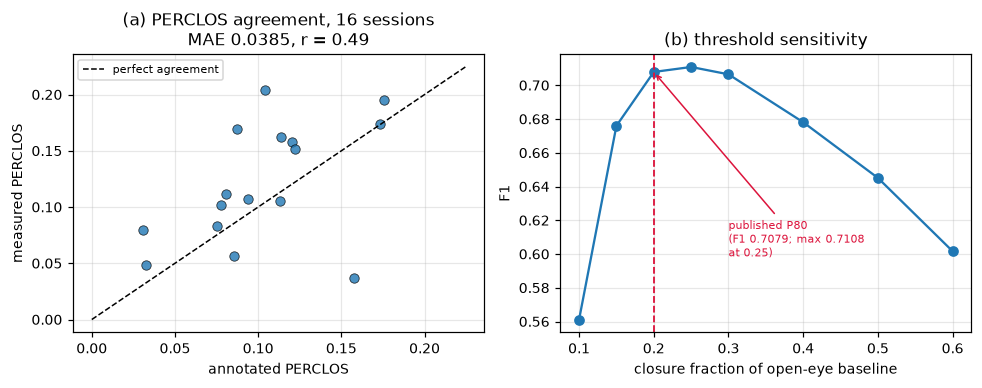

  fig_pad_tierC_vs_tierD       Tier-C synthetic vs Tier-D real PAD (P4 section6)


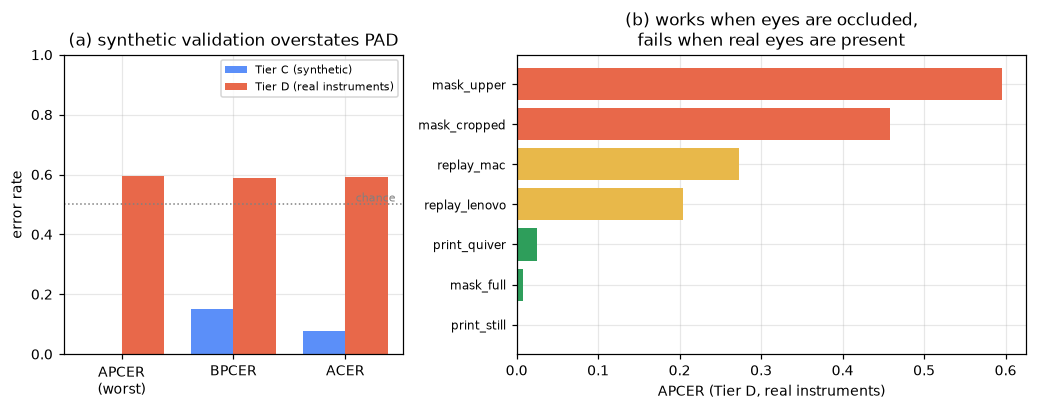

  fig_gate_g3_baselines        Gate G3 baseline comparison (P4 section7)


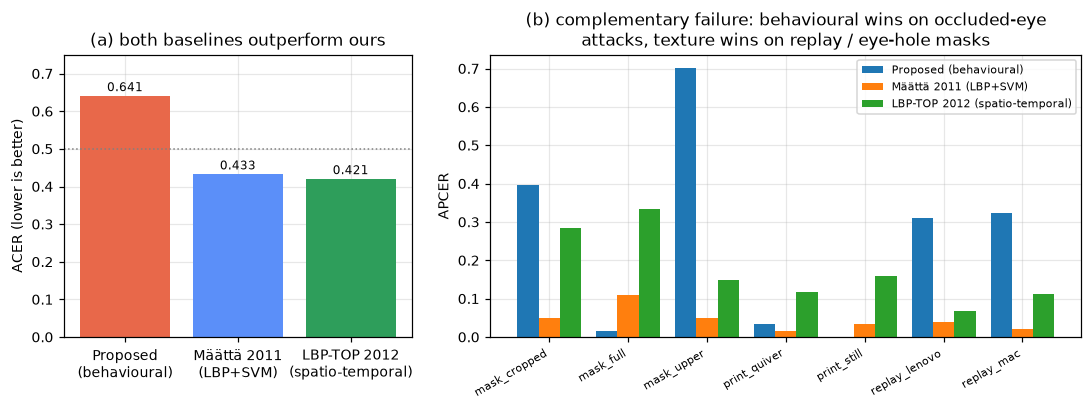

  fig_blink_diagnosis          Blink-rate diagnosis across corpora (P4 section6.2)


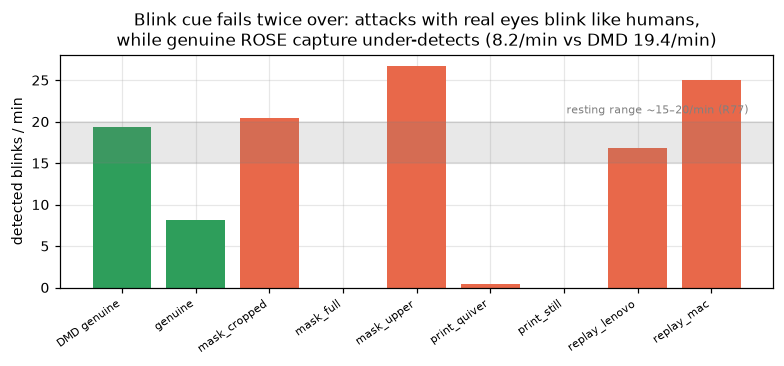

  fig_stride_table             STRIDE validation summary (P6)


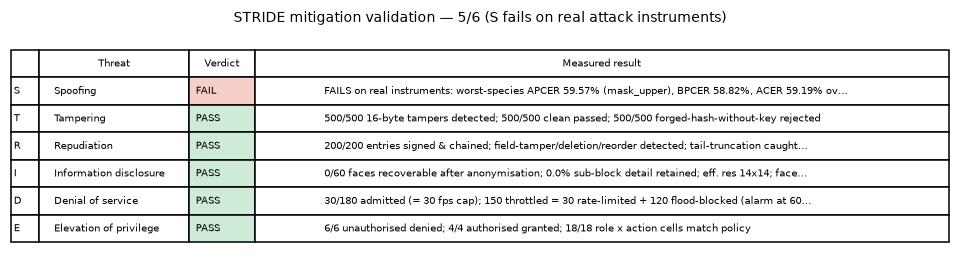

  fig_privacy_guard            Privacy anonymisation before/after (P6, STRIDE-I)


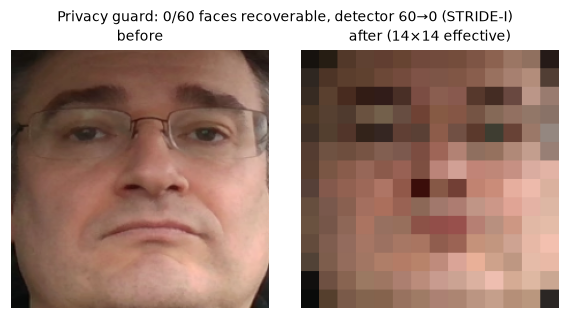


6 figures written to C:\Users\Ajitesh\Documents\Galway Notes\Adaptive Cybersecurity Project\dms_project_fixed_v3\dms_jupyter\outputs\figures (.png + .pdf, 300 dpi)


In [24]:
# BLOCK 24 — Generate thesis figures and export them as PNG and PDF files from the notebook results.

import matplotlib.pyplot as plt          # notebook's inline backend: figures RENDER here
from IPython.display import display

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"font.size": 9, "figure.dpi": 110, "savefig.dpi": 300,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})
_FIGS = []


def _save(fig, name, caption):
    # Write .png + .pdf for the thesis AND display the figure inline.
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight")
    _FIGS.append((name, caption))
    log(f"  {name:<28} {caption}")
    display(fig)                          # render in the notebook
    plt.close(fig)


log("\n" + "=" * 82)
log("P7-1 — figure export")
log("=" * 82)

# ── Fig 1: driver-state — PERCLOS agreement + threshold sensitivity ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
_pp = np.array([s["perclos_pred"] for s in P3_RESULTS["per_session"]])
_pt = np.array([s["perclos_truth"] for s in P3_RESULTS["per_session"]])
ax1.scatter(_pt, _pp, s=38, alpha=0.8, edgecolor="k", linewidth=0.5)
_lim = [0, max(_pp.max(), _pt.max()) * 1.1]
ax1.plot(_lim, _lim, "k--", lw=1, label="perfect agreement")
ax1.set_xlabel("annotated PERCLOS"); ax1.set_ylabel("measured PERCLOS")
ax1.set_title(f"(a) PERCLOS agreement, 16 sessions\nMAE {P3_RESULTS['perclos_mae']:.4f}, "
              f"r = {P3_RESULTS['perclos_pearson_r']:.2f}")
ax1.legend(fontsize=7)
# Read from THIS run's sweep (SENSITIVITY, section4.8) rather than literals.
# The values here used to be hardcoded from a superseded section4.5 sweep, and the
# annotation claimed P80 was the untuned OPTIMUM. Both were wrong: on all 16
# sessions through the deployed code path the maximum is at 0.25, and P80 is
# near-optimal rather than optimal. Hardcoding also contradicted this cell's
# own provenance rule.
_fracs = [r["fraction"] for r in SENSITIVITY["closure_fraction"]]
_f1s = [r["f1"] for r in SENSITIVITY["closure_fraction"]]
_best = max(range(len(_f1s)), key=lambda k: _f1s[k])
_p80 = _fracs.index(P80_CLOSURE_FRACTION)
ax2.plot(_fracs, _f1s, "o-", lw=1.5)
ax2.axvline(P80_CLOSURE_FRACTION, color="crimson", ls="--", lw=1.2)
ax2.annotate(f"published P80\n(F1 {_f1s[_p80]:.4f}; max {_f1s[_best]:.4f}\nat {_fracs[_best]:.2f})",
             xy=(P80_CLOSURE_FRACTION, _f1s[_p80]),
             xytext=(0.30, min(_f1s) + 0.25 * (max(_f1s) - min(_f1s))),
             fontsize=7, color="crimson",
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
ax2.set_xlabel("closure fraction of open-eye baseline"); ax2.set_ylabel("F1")
ax2.set_title("(b) threshold sensitivity")
fig.tight_layout()
_save(fig, "fig_driver_state", "PERCLOS agreement + threshold sensitivity (P3)")

# ── Fig 2: THE headline — synthetic (Tier C) vs real (Tier D) ──────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.5]})
_tc = [PAD_RESULTS["apcer_worst"], PAD_RESULTS["bpcer"], PAD_RESULTS["acer"]]
_td = [TIER_D_RESULTS["apcer_worst"], TIER_D_RESULTS["bpcer"], TIER_D_RESULTS["acer"]]
_x = np.arange(3)
ax1.bar(_x - 0.19, _tc, 0.38, label="Tier C (synthetic)", color="#5B8FF9")
ax1.bar(_x + 0.19, _td, 0.38, label="Tier D (real instruments)", color="#E8684A")
ax1.axhline(0.5, color="gray", ls=":", lw=1)
ax1.text(2.45, 0.51, "chance", fontsize=7, color="gray", ha="right")
ax1.set_xticks(_x); ax1.set_xticklabels(["APCER\n(worst)", "BPCER", "ACER"])
ax1.set_ylabel("error rate"); ax1.set_ylim(0, 1)
ax1.set_title("(a) synthetic validation overstates PAD")
ax1.legend(fontsize=7)
_sp = sorted(TIER_D_RESULTS["apcer_per_species"], key=TIER_D_RESULTS["apcer_per_species"].get)
_vals = [TIER_D_RESULTS["apcer_per_species"][s] for s in _sp]
_cols = ["#2E9E5B" if v < 0.05 else "#E8B84A" if v < 0.3 else "#E8684A" for v in _vals]
ax2.barh(range(len(_sp)), _vals, color=_cols)
ax2.set_yticks(range(len(_sp))); ax2.set_yticklabels(_sp, fontsize=8)
ax2.set_xlabel("APCER (Tier D, real instruments)")
ax2.set_title("(b) works when eyes are occluded,\nfails when real eyes are present")
fig.tight_layout()
_save(fig, "fig_pad_tierC_vs_tierD", "Tier-C synthetic vs Tier-D real PAD (P4 section6)")

# ── Fig 3: gate G3 — proposed vs published baselines ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.7]})
_methods = [("ours", "Proposed\n(behavioural)"), ("maatta_R73", "Määttä 2011\n(LBP+SVM)"),
            ("lbptop_R74", "LBP-TOP 2012\n(spatio-temporal)")]
_acers = [G3[k]["acer"] for k, _ in _methods]
ax1.bar([n for _, n in _methods], _acers,
        color=["#E8684A", "#5B8FF9", "#2E9E5B"])
ax1.axhline(0.5, color="gray", ls=":", lw=1)
for i, v in enumerate(_acers):
    ax1.text(i, v + 0.012, f"{v:.3f}", ha="center", fontsize=8)
ax1.set_ylabel("ACER (lower is better)"); ax1.set_ylim(0, 0.75)
ax1.set_title("(a) both baselines outperform ours")
_species = sorted(G3["ours"]["apcer_per_species"])
_w, _xx = 0.27, np.arange(len(_species))
for _i, (_k, _lbl) in enumerate(_methods):
    ax2.bar(_xx + (_i - 1) * _w, [G3[_k]["apcer_per_species"].get(s, 0) for s in _species],
            _w, label=_lbl.replace("\n", " "))
ax2.set_xticks(_xx); ax2.set_xticklabels(_species, rotation=30, ha="right", fontsize=7)
ax2.set_ylabel("APCER"); ax2.legend(fontsize=7)
ax2.set_title("(b) complementary failure: behavioural wins on occluded-eye\n"
              "attacks, texture wins on replay / eye-hole masks")
fig.tight_layout()
_save(fig, "fig_gate_g3_baselines", "Gate G3 baseline comparison (P4 section7)")

# ── Fig 4: why it fails — blink rate by class, both corpora ───────────────
_diag = json.loads((OUT_DIR / "p4d_failure_diagnostic.json").read_text(encoding="utf-8"))
fig, ax = plt.subplots(figsize=(7.2, 3.4))
_names = [k for k in _diag if k != "DMD genuine"]
_names = ["DMD genuine"] + sorted(_names)
_rates = [_diag[n]["blinks_per_min"] for n in _names]
_c = ["#2E9E5B" if "genuine" in n else "#E8684A" for n in _names]
ax.bar(range(len(_names)), _rates, color=_c)
# P7-2 correction: the band used to read "15-30/min (R20)". That value AND
# that source were both wrong - R20 is an anti-spoofing survey. The
# supportable resting range is ~15-20/min (R77, Bentivoglio et al. 1997,
# mean 17/min over 150 subjects).
ax.axhspan(15, 20, color="gray", alpha=0.18)
ax.text(len(_names) - 0.5, 21, "resting range ~15–20/min (R77)",
        fontsize=7, ha="right", color="gray")
ax.set_xticks(range(len(_names)))
ax.set_xticklabels([n.replace("ROSE ", "") for n in _names], rotation=35, ha="right", fontsize=7)
ax.set_ylabel("detected blinks / min")
ax.set_title("Blink cue fails twice over: attacks with real eyes blink like humans,\n"
             "while genuine ROSE capture under-detects (8.2/min vs DMD 19.4/min)")
fig.tight_layout()
_save(fig, "fig_blink_diagnosis", "Blink-rate diagnosis across corpora (P4 section6.2)")

# ── Fig 5: STRIDE summary table ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis("off")
_rows = [[k, STRIDE[k]["threat"], "PASS" if STRIDE[k]["pass"] else "FAIL",
          (STRIDE[k]["result"][:96] + "…") if len(STRIDE[k]["result"]) > 96
          else STRIDE[k]["result"]] for k in ("S", "T", "R", "I", "D", "E")]
_t = ax.table(cellText=_rows, colLabels=["", "Threat", "Verdict", "Measured result"],
              cellLoc="left", loc="center", colWidths=[0.03, 0.16, 0.07, 0.74])
_t.auto_set_font_size(False); _t.set_fontsize(6.5); _t.scale(1, 1.5)
for _i, _k in enumerate(("S", "T", "R", "I", "D", "E"), start=1):
    _t[(_i, 2)].set_facecolor("#CDEBD6" if STRIDE[_k]["pass"] else "#F6CFC8")
ax.set_title("STRIDE mitigation validation — 5/6 (S fails on real attack instruments)",
             fontsize=9, pad=12)
_save(fig, "fig_stride_table", "STRIDE validation summary (P6)")

# ── Fig 6: privacy guard before/after ─────────────────────────────────────
_cap = cv2.VideoCapture(str(dmd_inventory["drowsiness"]["videos"][0]))
_cap.set(cv2.CAP_PROP_POS_FRAMES, 600)
_ok, _bgr = _cap.read(); _cap.release()
_lm = make_landmarker(video_mode=False)
_r = _lm.detect(mp.Image(image_format=mp.ImageFormat.SRGB,
                         data=np.ascontiguousarray(cv2.cvtColor(_bgr, cv2.COLOR_BGR2RGB))))
if _r.face_landmarks:
    _h, _w = _bgr.shape[:2]
    _px = np.array([[p.x * _w, p.y * _h] for p in _r.face_landmarks[0]])
    _x0, _y0 = max(int(_px[:, 0].min()), 0), max(int(_px[:, 1].min()), 0)
    _x1, _y1 = min(int(_px[:, 0].max()), _w), min(int(_px[:, 1].max()), _h)
    _face = cv2.cvtColor(cv2.resize(_bgr[_y0:_y1, _x0:_x1], (224, 224)), cv2.COLOR_BGR2RGB)
    _prot = PrivacyGuard().protect(_face)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(5.4, 2.9))
    for _a, _im, _ttl in ((a1, _face, "before"), (a2, _prot, "after (14×14 effective)")):
        _a.imshow(_im); _a.axis("off"); _a.set_title(_ttl, fontsize=9)
    fig.suptitle("Privacy guard: 0/60 faces recoverable, detector 60→0 (STRIDE-I)", fontsize=9)
    fig.tight_layout()
    _save(fig, "fig_privacy_guard", "Privacy anonymisation before/after (P6, STRIDE-I)")

log(f"\n{len(_FIGS)} figures written to {FIG_DIR} (.png + .pdf, 300 dpi)")